# Laboratorio Spark: salarios de personas asalariadas en Guatemala (ENEIC)

## Parte 1. Carga, preparación y auditoría de los datos

**Herramientas:** Python, Spark 3.5 (DataFrames y `pyspark.ml`).
**Fuente:** Encuesta Nacional de Empleo e Ingresos Continua (ENEIC), bases de *Personas*, INE Guatemala.
**Uso de los datos:** los cuatro trimestres de 2025 forman el conjunto de desarrollo (*train*) y el primer trimestre de 2026 es la prueba final (*test*).

En esta parte se hace lo siguiente:

1. Configurar Spark y las rutas.
2. Leer cada archivo por separado, seleccionar las columnas requeridas, homologar tipos y guardar en Parquet.
3. Unir los cuatro archivos de 2025 con `unionByName` y auditar la unión (esquema, conteos, faltantes, claves).
4. Aplicar los filtros de la población analítica, siempre en el mismo orden, contando las exclusiones de cada paso.
5. Validar las variables categóricas y construir la antigüedad en años.
6. Guardar el conjunto preparado de 2025 y el de 2026 por separado en Parquet.

Todas las estadísticas y conteos se calculan con Spark sobre el conjunto completo. A pandas solo se pasan tablas pequeñas ya agregadas.

## 0. Configuración y sesión de Spark

In [1]:
# Si se usa Colab u otro entorno sin Spark, descomente la siguiente línea:
# !pip install -q pyspark==3.5.1 openpyxl

import json
import math
import re
from functools import reduce
from pathlib import Path

import pandas as pd
from IPython.display import display

from pyspark.sql import SparkSession, functions as F, types as T
pd.set_option("display.max_columns", 60)
pd.set_option("display.width", 220)
pd.set_option("display.max_colwidth", 80)

In [2]:

DIR_DATOS  = Path("datos").resolve()    
DIR_SALIDA = Path("salidas").resolve()  
HOJA       = 0                            

ARCHIVOS = {
    "2025T1": "Personas_ENEIC_T1_2025.xlsx",
    "2025T2": "Personas-ENEIC-T2-2025.xlsx",
    "2025T3": "Base-de-datos-Personas-ENEIC-III-2025.xlsx",
    "2025T4": "Base-de-datos-Personas-ENEIC-IV-2025.xlsx",
    "2026T1": "Base-de-datos-Personas-ENEIC-I-2026.xlsx",
}
PERIODOS_TRAIN = ["2025T1", "2025T2", "2025T3", "2025T4"]
PERIODO_TEST   = "2026T1"


FORZAR_LECTURA = False


ESPERADOS = {
    "2025T1": (51588, 270),
    "2025T2": (51167, 270),
    "2025T3": (51583, 270),
    "2025T4": (49338, 302),
    "2026T1": (49843, 270),
}

ETIQUETAS_NIVEL_EDUCATIVO = {   
    "0": "Ninguno", "1": "Preprimaria", "2": "Primaria", "3": "Básico",
    "4": "Diversificado", "5": "Superior", "6": "Maestría", "7": "Doctorado",
}
ETIQUETAS_DOMINIO = {           
    "1": "Urbano Metropolitano", "2": "Resto Urbano", "3": "Rural Nacional",
}

CODIGOS_VALIDOS = {
    "nivel_educativo": list(ETIQUETAS_NIVEL_EDUCATIVO),
    "dominio": list(ETIQUETAS_DOMINIO),
}


CATEGORIAS_ASALARIADO = {
    "1": "Empleado de gobierno",
    "2": "Empleado de empresa privada",
    "3": "Empleado jornalero o peón",
    "4": "Servicio doméstico",
}

In [3]:
spark = (
    SparkSession.builder
    .appName("ENEIC_salarios_parte1")
    .master("local[*]")
    .config("spark.sql.shuffle.partitions", "8")
    .config("spark.driver.memory", "4g")
    .getOrCreate()
)
spark.sparkContext.setLogLevel("WARN")
print("Spark", spark.version)

(DIR_SALIDA / "raw").mkdir(parents=True, exist_ok=True)
(DIR_SALIDA / "preparado").mkdir(parents=True, exist_ok=True)

Setting default log level to "WARN".
To adjust logging level use sc.setLogLevel(newLevel). For SparkR, use setLogLevel(newLevel).


26/09/24 22:25:48 WARN NativeCodeLoader: Unable to load native-hadoop library for your platform... using builtin-java classes where applicable


Spark 3.5.1


## 1. Carga de los archivos, homologación de tipos y Parquet

**Estrategia:**

- Spark no lee Excel de forma nativa. Cada archivo se lee **individualmente** con pandas/openpyxl, conservando solo las 14 columnas necesarias (así no se carga en memoria las 270 o 302 columnas originales).
- Los nombres de columna se normalizan (mayúsculas y sin espacios) y se buscan **por nombre**, nunca por posición.
- Los **códigos** (`OCUPADOS`, `P05C16`, `P03A03A`, `DOMINIO`, `NUM_HOGAR`, `NUM_PERSONA`) se convierten a una representación de texto consistente: `1`, `1.0` y `"01"` pasan a ser `"1"`. Un mismo código puede llegar como número o como texto. El código `0` se conserva como `"0"`; no se trata como faltante.
- Las variables **numéricas** se convierten a `double`. Lo que no puede interpretarse como número queda como nulo (así se cuenta como faltante y no se evalúa como válido).
- Cada archivo se convierte a un DataFrame de Spark con **esquema explícito** y se guarda en Parquet. Se agregan `archivo_origen`, `periodo_archivo`, `anio_archivo` y `trimestre_calendario`, tomados del **archivo de procedencia**. La columna original `TRIMESTRE` se conserva tal cual y no se usa para el calendario.

| Variable original | Nombre analítico | Uso |
|---|---|---|
| P05D01 | salario_mensual | Variable objetivo |
| P02A03 | edad | Predictor numérico |
| P05C07A / P05C07B | antiguedad_anios / antiguedad_meses | Construcción de antigüedad |
| P05H01A | horas_semanales | Predictor y clustering |
| P03A03A | nivel_educativo | Predictor categórico |
| P05C16 | categoria_ocupacional | Filtro y predictor categórico |
| DOMINIO | dominio | Predictor categórico |
| OCUPADOS | ocupado | Filtro |
| NUM_HOGAR, NUM_PERSONA | (se conservan) | Auditoría de registros |
| FACTOR | (se conserva) | Documentación del diseño muestral |
| ANIO, TRIMESTRE | (se conservan) | Auditoría de la fuente |

In [4]:
COLUMNAS_ORIGINALES = {
    "TRIMESTRE", "ANIO", "NUM_HOGAR", "NUM_PERSONA", "FACTOR", "OCUPADOS",
    "P02A03", "P05C07A", "P05C07B", "P05H01A", "P03A03A", "P05C16", "DOMINIO", "P05D01",
}

# Esquema explícito de cada DataFrame de Spark (orden de columnas fijo)
SCHEMA = T.StructType([
    T.StructField("archivo_origen",          T.StringType()),
    T.StructField("periodo_archivo",         T.StringType()),
    T.StructField("anio_archivo",            T.IntegerType()),
    T.StructField("trimestre_calendario",    T.IntegerType()),
    T.StructField("ANIO",                    T.IntegerType()),   # original
    T.StructField("TRIMESTRE",               T.IntegerType()),   # original
    T.StructField("NUM_HOGAR",               T.StringType()),
    T.StructField("NUM_PERSONA",             T.StringType()),
    T.StructField("FACTOR",                  T.DoubleType()),
    T.StructField("ocupado",                 T.StringType()),    # OCUPADOS
    T.StructField("edad",                    T.DoubleType()),    # P02A03
    T.StructField("antiguedad_anios",        T.DoubleType()),    # P05C07A
    T.StructField("antiguedad_meses",        T.DoubleType()),    # P05C07B
    T.StructField("horas_semanales",         T.DoubleType()),    # P05H01A
    T.StructField("nivel_educativo",         T.StringType()),    # P03A03A
    T.StructField("categoria_ocupacional",   T.StringType()),    # P05C16
    T.StructField("dominio",                 T.StringType()),    # DOMINIO
    T.StructField("salario_mensual",         T.DoubleType()),    # P05D01
])
COLUMNAS_SELECCIONADAS = [f.name for f in SCHEMA.fields]
VARIABLES_ANALITICAS = [c for c in COLUMNAS_SELECCIONADAS
                        if c not in ("archivo_origen", "periodo_archivo", "anio_archivo", "trimestre_calendario")]

In [5]:

def parse_periodo(periodo):
    # "2025T1" -> (2025, 1)
    m = re.fullmatch(r"(\d{4})T([1-4])", periodo)
    if not m:
        raise ValueError(f"Periodo con formato inesperado: {periodo!r} (se espera, por ejemplo, '2025T1')")
    return int(m.group(1)), int(m.group(2))


def normalizar_codigo(x):

    if x is None or x is pd.NA:
        return None
    if isinstance(x, float) and math.isnan(x):
        return None
    s = str(x).strip()
    if s == "" or s.lower() in {"nan", "none", "null", "<na>"}:
        return None
    try:
        v = float(s)
        if math.isfinite(v) and v == int(v):
            return str(int(v))
    except ValueError:
        pass
    return s.upper()


def leer_seleccion(ruta):

    ruta = Path(ruta)
    es_csv = ruta.suffix.lower() == ".csv"
    if es_csv:
        encabezado = pd.read_csv(ruta, nrows=0)
    else:
        encabezado = pd.read_excel(ruta, sheet_name=HOJA, nrows=0)
    columnas_up = [str(c).strip().upper() for c in encabezado.columns]

    ausentes = sorted(COLUMNAS_ORIGINALES - set(columnas_up))
    if ausentes:
        raise ValueError(f"{ruta.name}: faltan columnas requeridas: {ausentes}")

    filtro = lambda c: str(c).strip().upper() in COLUMNAS_ORIGINALES
    if es_csv:
        pdf = pd.read_csv(ruta, usecols=filtro, dtype=object)
    else:
        pdf = pd.read_excel(ruta, sheet_name=HOJA, usecols=filtro, dtype=object)
    pdf.columns = [str(c).strip().upper() for c in pdf.columns]
    if pdf.columns.duplicated().any():
        raise ValueError(f"{ruta.name}: nombres de columna repetidos tras normalizar: "
                         f"{list(pdf.columns[pdf.columns.duplicated()])}")

    num = lambda s: pd.to_numeric(s, errors="coerce")
    out = pd.DataFrame({
        "ANIO":                  num(pdf["ANIO"]),
        "TRIMESTRE":             num(pdf["TRIMESTRE"]),
        "NUM_HOGAR":             pdf["NUM_HOGAR"].map(normalizar_codigo),
        "NUM_PERSONA":           pdf["NUM_PERSONA"].map(normalizar_codigo),
        "FACTOR":                num(pdf["FACTOR"]),
        "ocupado":               pdf["OCUPADOS"].map(normalizar_codigo),
        "edad":                  num(pdf["P02A03"]),
        "antiguedad_anios":      num(pdf["P05C07A"]),
        "antiguedad_meses":      num(pdf["P05C07B"]),
        "horas_semanales":       num(pdf["P05H01A"]),
        "nivel_educativo":       pdf["P03A03A"].map(normalizar_codigo),
        "categoria_ocupacional": pdf["P05C16"].map(normalizar_codigo),
        "dominio":               pdf["DOMINIO"].map(normalizar_codigo),
        "salario_mensual":       num(pdf["P05D01"]),
    })
    meta = {"archivo": ruta.name, "n_registros": int(len(pdf)),
            "n_columnas": len(columnas_up), "columnas": columnas_up}
    return out, meta


def _a_python(v, tipo):

    if v is None or v is pd.NA:
        return None
    if isinstance(v, float) and math.isnan(v):
        return None
    if isinstance(tipo, T.IntegerType):
        return int(v)
    if isinstance(tipo, T.DoubleType):
        return float(v)
    return str(v)


def a_filas(pdf):
    tipos = [f.dataType for f in SCHEMA.fields]
    return [tuple(_a_python(v, t) for v, t in zip(fila, tipos))
            for fila in pdf[COLUMNAS_SELECCIONADAS].itertuples(index=False, name=None)]


def cargar_archivo(periodo):

    ruta_pq   = DIR_SALIDA / "raw" / f"{periodo}.parquet"
    ruta_meta = DIR_SALIDA / "raw" / f"{periodo}_meta.json"
    if ruta_pq.exists() and ruta_meta.exists() and not FORZAR_LECTURA:
        meta = json.loads(ruta_meta.read_text(encoding="utf-8"))
        return spark.read.parquet(str(ruta_pq)), meta

    archivo = DIR_DATOS / ARCHIVOS[periodo]
    pdf, meta = leer_seleccion(archivo)
    anio, trim = parse_periodo(periodo)
    pdf.insert(0, "archivo_origen", archivo.name)
    pdf.insert(1, "periodo_archivo", periodo)
    pdf.insert(2, "anio_archivo", anio)
    pdf.insert(3, "trimestre_calendario", trim)

    sdf = spark.createDataFrame(a_filas(pdf), schema=SCHEMA)
    sdf.write.mode("overwrite").parquet(str(ruta_pq))
    ruta_meta.write_text(json.dumps(meta), encoding="utf-8")
    del pdf
    return spark.read.parquet(str(ruta_pq)), meta

In [6]:
dfs, meta_archivos = {}, {}
for periodo in ARCHIVOS:
    dfs[periodo], meta_archivos[periodo] = cargar_archivo(periodo)
    m = meta_archivos[periodo]
    print(f"{periodo}: {m['archivo']:<40s} {m['n_registros']:>7,} registros | {m['n_columnas']} columnas originales")

2025T1: Personas_ENEIC_T1_2025.xlsx               51,588 registros | 270 columnas originales


2025T2: Personas-ENEIC-T2-2025.xlsx               51,167 registros | 270 columnas originales


2025T3: Base-de-datos-Personas-ENEIC-III-2025.xlsx  51,583 registros | 270 columnas originales


2025T4: Base-de-datos-Personas-ENEIC-IV-2025.xlsx  49,338 registros | 302 columnas originales


2026T1: Base-de-datos-Personas-ENEIC-I-2026.xlsx  49,843 registros | 270 columnas originales


### 1.1 Verificación contra los conteos del enunciado

In [7]:
verif = pd.DataFrame([{
    "periodo_archivo": p,
    "archivo_origen": meta_archivos[p]["archivo"],
    "registros_leidos": meta_archivos[p]["n_registros"],
    "registros_esperados": ESPERADOS[p][0],
    "columnas_leidas": meta_archivos[p]["n_columnas"],
    "columnas_esperadas": ESPERADOS[p][1],
    "coincide": (meta_archivos[p]["n_registros"], meta_archivos[p]["n_columnas"]) == ESPERADOS[p],
} for p in ARCHIVOS])
display(verif)
if not verif["coincide"].all():
    print("ATENCIÓN: hay archivos cuyos conteos no coinciden con el enunciado. Revise nombres de archivo y hoja (HOJA).")

,periodo_archivo,archivo_origen,registros_leidos,registros_esperados,columnas_leidas,columnas_esperadas,coincide
0,2025T1,Personas_ENEIC_T1_2025.xlsx,51588,51588,270,270,True
1,2025T2,Personas-ENEIC-T2-2025.xlsx,51167,51167,270,270,True
2,2025T3,Base-de-datos-Personas-ENEIC-III-2025.xlsx,51583,51583,270,270,True
3,2025T4,Base-de-datos-Personas-ENEIC-IV-2025.xlsx,49338,49338,302,302,True
4,2026T1,Base-de-datos-Personas-ENEIC-I-2026.xlsx,49843,49843,270,270,True


### 1.2 Posición de las variables en cada archivo original

La tabla muestra la posición (base 1) que ocupa cada variable requerida en el archivo original. Sirve para comprobar si una unión por posición sería segura.

In [8]:
pos = pd.DataFrame({
    p: {c: m["columnas"].index(c) + 1 for c in sorted(COLUMNAS_ORIGINALES)}
    for p, m in meta_archivos.items()
})
pos["misma_posicion_en_todos"] = pos.nunique(axis=1) == 1
display(pos)

base = meta_archivos["2025T1"]["columnas"]
for p in ARCHIVOS:
    cols = meta_archivos[p]["columnas"]
    extra   = [c for c in cols if c not in set(base)]
    ausente = [c for c in base if c not in set(cols)]
    print(f"{p}: {len(cols)} columnas | no están en 2025T1: {len(extra)} | de 2025T1 que no trae: {len(ausente)}")
    if extra and p == "2025T4":
        print("   Ejemplos de columnas adicionales:", extra[:10])

n_mov = int((~pos["misma_posicion_en_todos"]).sum())
print(f"\nVariables requeridas que cambian de posición entre archivos: {n_mov} de {len(pos)}")

,2025T1,2025T2,2025T3,2025T4,2026T1,misma_posicion_en_todos
ANIO,1,1,1,1,1,True
DOMINIO,3,3,3,3,3,True
FACTOR,5,5,5,5,5,True
NUM_HOGAR,4,4,4,4,4,True
NUM_PERSONA,7,7,7,7,7,True
OCUPADOS,266,266,266,298,266,False
P02A03,13,13,13,9,13,False
P03A03A,33,33,33,29,33,False
P05C07A,68,68,68,61,68,False
P05C07B,69,69,69,62,69,False


2025T1: 270 columnas | no están en 2025T1: 0 | de 2025T1 que no trae: 0
2025T2: 270 columnas | no están en 2025T1: 0 | de 2025T1 que no trae: 0
2025T3: 270 columnas | no están en 2025T1: 0 | de 2025T1 que no trae: 0
2025T4: 302 columnas | no están en 2025T1: 42 | de 2025T1 que no trae: 10
   Ejemplos de columnas adicionales: ['P07A01A', 'P07A01B', 'P07A01C', 'P07A02A', 'P07A02B', 'P07A02C', 'P07A03A', 'P07A03B', 'P07A03C', 'P07A04A']
2026T1: 270 columnas | no están en 2025T1: 0 | de 2025T1 que no trae: 0

Variables requeridas que cambian de posición entre archivos: 8 de 14


**¿Por qué IV de 2025 no puede apilarse por posición de columnas con los otros archivos?**

El archivo de IV de 2025 trae 302 columnas y los otros cuatro traen 270. Un `union` de Spark empareja las columnas por su **posición**, no por su nombre; esto solo es correcto si la columna *k* significa lo mismo en todos los archivos.

- Con distinto número de columnas, `union` ni siquiera se puede ejecutar.
- Si se recortaran los archivos al mismo número de columnas, las variables que cambian de posición (véase la tabla anterior) quedarían **mezcladas**: en una misma columna quedarían, por ejemplo, edades de un archivo y códigos de otra pregunta de otro archivo. Si los tipos son compatibles, Spark no avisaría del error.

`unionByName` empareja por **nombre**, por lo que es seguro siempre que los nombres estén homologados (mayúsculas y espacios) y todos los DataFrames tengan las mismas columnas con los mismos tipos. Eso es lo que se hizo antes de unir: se seleccionaron por nombre las mismas 14 columnas de cada archivo y se les dio el mismo esquema.

## 2. Unión de los cuatro archivos de 2025 con `unionByName`

El conjunto de 2026 (prueba final) se mantiene **separado** y recibe exactamente el mismo tratamiento, pero no se usa para tomar decisiones de análisis.

In [9]:
df_2025 = reduce(lambda a, b: a.unionByName(b), [dfs[p] for p in PERIODOS_TRAIN]).cache()
df_2026 = dfs[PERIODO_TEST].cache()
df_todo = df_2025.unionByName(df_2026)

print(f"Registros 2025 (4 archivos): {df_2025.count():,}")
print(f"Registros 2026T1:            {df_2026.count():,}")

Registros 2025 (4 archivos): 203,676


Registros 2026T1:            49,843


### 2.1 Esquema y cinco registros de las columnas seleccionadas

In [10]:
df_2025.printSchema()
display(df_2025.limit(5).toPandas())

root
 |-- archivo_origen: string (nullable = true)
 |-- periodo_archivo: string (nullable = true)
 |-- anio_archivo: integer (nullable = true)
 |-- trimestre_calendario: integer (nullable = true)
 |-- ANIO: integer (nullable = true)
 |-- TRIMESTRE: integer (nullable = true)
 |-- NUM_HOGAR: string (nullable = true)
 |-- NUM_PERSONA: string (nullable = true)
 |-- FACTOR: double (nullable = true)
 |-- ocupado: string (nullable = true)
 |-- edad: double (nullable = true)
 |-- antiguedad_anios: double (nullable = true)
 |-- antiguedad_meses: double (nullable = true)
 |-- horas_semanales: double (nullable = true)
 |-- nivel_educativo: string (nullable = true)
 |-- categoria_ocupacional: string (nullable = true)
 |-- dominio: string (nullable = true)
 |-- salario_mensual: double (nullable = true)



,archivo_origen,periodo_archivo,anio_archivo,trimestre_calendario,ANIO,TRIMESTRE,NUM_HOGAR,NUM_PERSONA,FACTOR,ocupado,edad,antiguedad_anios,antiguedad_meses,horas_semanales,nivel_educativo,categoria_ocupacional,dominio,salario_mensual
0,Personas_ENEIC_T1_2025.xlsx,2025T1,2025,1,2025,2,16033,2,356.0,1,44.0,6.0,0.0,50.0,5,1,2,5691.0
1,Personas_ENEIC_T1_2025.xlsx,2025T1,2025,1,2025,2,16034,2,103.0,1,59.0,0.0,2.0,20.0,0,5,2,NaN
2,Personas_ENEIC_T1_2025.xlsx,2025T1,2025,1,2025,2,16034,1,103.0,1,64.0,0.0,3.0,48.0,0,7,2,NaN
3,Personas_ENEIC_T1_2025.xlsx,2025T1,2025,1,2025,2,16034,6,103.0,NaN,10.0,NaN,NaN,NaN,2,NaN,2,NaN
4,Personas_ENEIC_T1_2025.xlsx,2025T1,2025,1,2025,2,16034,7,103.0,NaN,2.0,NaN,NaN,NaN,NaN,NaN,2,NaN


### 2.2 Identificación del período
`periodo_archivo`, `anio_archivo` y `trimestre_calendario` provienen del **archivo de procedencia**. `TRIMESTRE` se conserva como vino. La tabla siguiente muestra los valores originales de `TRIMESTRE` por archivo.

In [11]:
display(
    df_todo.groupBy("periodo_archivo", "archivo_origen", "anio_archivo", "trimestre_calendario", "TRIMESTRE")
    .count().orderBy("periodo_archivo", "TRIMESTRE").toPandas()
)

,periodo_archivo,archivo_origen,anio_archivo,trimestre_calendario,TRIMESTRE,count
0,2025T1,Personas_ENEIC_T1_2025.xlsx,2025,1,2,51588
1,2025T2,Personas-ENEIC-T2-2025.xlsx,2025,2,2,175
2,2025T2,Personas-ENEIC-T2-2025.xlsx,2025,2,3,50992
3,2025T3,Base-de-datos-Personas-ENEIC-III-2025.xlsx,2025,3,4,51583
4,2025T4,Base-de-datos-Personas-ENEIC-IV-2025.xlsx,2025,4,5,49338
5,2026T1,Base-de-datos-Personas-ENEIC-I-2026.xlsx,2026,1,6,49843


Según el enunciado, `TRIMESTRE` vale 2, 3, 4, 5 y 6 para los cinco archivos, y el archivo II de 2025 contiene además 175 registros con valor 2. Por eso **no** se resta uno automáticamente a `TRIMESTRE`: esa operación no resolvería todos los registros observados. El período calendario se asigna por archivo, lo que identifica el corte publicado al que pertenece cada registro sin modificar la respuesta original.

## 3. Registros y faltantes antes de aplicar filtros

In [12]:
antes = (df_todo.groupBy("periodo_archivo", "archivo_origen").count()
         .orderBy("periodo_archivo").toPandas().rename(columns={"count": "registros_originales"}))
display(antes)

,periodo_archivo,archivo_origen,registros_originales
0,2025T1,Personas_ENEIC_T1_2025.xlsx,51588
1,2025T2,Personas-ENEIC-T2-2025.xlsx,51167
2,2025T3,Base-de-datos-Personas-ENEIC-III-2025.xlsx,51583
3,2025T4,Base-de-datos-Personas-ENEIC-IV-2025.xlsx,49338
4,2026T1,Base-de-datos-Personas-ENEIC-I-2026.xlsx,49843


In [13]:
def tabla_faltantes(df, columnas):
    # Cantidad y porcentaje de nulos (y NaN en columnas double) por variable, calculados en Spark
    total = df.count()
    exprs = []
    for c in columnas:
        cond = F.col(c).isNull()
        if isinstance(df.schema[c].dataType, T.DoubleType):
            cond = cond | F.isnan(F.col(c))
        exprs.append(F.sum(cond.cast("int")).alias(c))
    fila = df.agg(*exprs).collect()[0].asDict()
    return pd.DataFrame({
        "variable": columnas,
        "faltantes": [int(fila[c] or 0) for c in columnas],
        "pct_faltantes": [round(100 * (fila[c] or 0) / total, 2) if total else float("nan") for c in columnas],
    }).set_index("variable")


falt_2025 = tabla_faltantes(df_2025, VARIABLES_ANALITICAS)
falt_2026 = tabla_faltantes(df_2026, VARIABLES_ANALITICAS)
faltantes = falt_2025.join(falt_2026, lsuffix="_2025", rsuffix="_2026T1")
print("Faltantes por variable ANTES de aplicar filtros (todas las personas de cada archivo):")
display(faltantes)

Faltantes por variable ANTES de aplicar filtros (todas las personas de cada archivo):


,faltantes_2025,pct_faltantes_2025,faltantes_2026T1,pct_faltantes_2026T1
variable,,,,
ANIO,0,0.00,0,0.00
TRIMESTRE,0,0.00,0,0.00
NUM_HOGAR,0,0.00,0,0.00
NUM_PERSONA,0,0.00,0,0.00
FACTOR,0,0.00,0,0.00
ocupado,115454,56.69,28109,56.40
edad,0,0.00,0,0.00
antiguedad_anios,115454,56.69,28109,56.40
antiguedad_meses,115454,56.69,28109,56.40


La tabla anterior mezcla dos situaciones muy distintas. Para separarlas, la siguiente tabla mide los faltantes **solo entre las personas a quienes sí corresponden las preguntas laborales**: ocupadas y con categoría ocupacional de asalariado (códigos 1 a 4).

In [14]:
def es_asalariado_ocupado():
    return (F.col("ocupado") == "1") & F.col("categoria_ocupacional").isin(list(CATEGORIAS_ASALARIADO))

vars_laborales = ["edad", "antiguedad_anios", "antiguedad_meses", "horas_semanales",
                  "nivel_educativo", "dominio", "salario_mensual"]
sub_2025 = df_2025.filter(es_asalariado_ocupado())
sub_2026 = df_2026.filter(es_asalariado_ocupado())
print(f"Ocupados asalariados (antes de filtros de calidad): 2025 = {sub_2025.count():,} | 2026T1 = {sub_2026.count():,}")
falt_sub = tabla_faltantes(sub_2025, vars_laborales).join(
    tabla_faltantes(sub_2026, vars_laborales), lsuffix="_2025", rsuffix="_2026T1")
display(falt_sub)

Ocupados asalariados (antes de filtros de calidad): 2025 = 53,025 | 2026T1 = 13,258


,faltantes_2025,pct_faltantes_2025,faltantes_2026T1,pct_faltantes_2026T1
variable,,,,
edad,0,0.0,0,0.0
antiguedad_anios,0,0.0,0,0.0
antiguedad_meses,0,0.0,0,0.0
horas_semanales,0,0.0,0,0.0
nivel_educativo,0,0.0,0,0.0
dominio,0,0.0,0,0.0
salario_mensual,0,0.0,0,0.0


**¿Qué diferencia existe entre un dato ausente porque la pregunta no corresponde y una respuesta no registrada?**

- **La pregunta no corresponde (falta estructural).** El cuestionario tiene saltos: a una persona que no trabajó no se le pregunta la antigüedad, las horas ni el salario de su ocupación. Ese vacío significa "no aplica" y no es un error. Por eso, en la primera tabla, las variables laborales tienen porcentajes altos de faltantes: los archivos incluyen a todas las personas, ocupadas o no. Estos vacíos **no se imputan**; se resuelven definiendo bien la población analítica.
- **Respuesta no registrada (no respuesta o error de captura).** La persona sí estaba en el universo de la pregunta (ocupada y asalariada) pero el valor quedó vacío o inválido: no sabe, no quiso responder, error de captura. Esto sí es un problema de calidad y es lo que muestra la segunda tabla. Puede sesgar los resultados si quienes no declaran salario son distintos de quienes lo declaran.

Por esta razón los faltantes se miden sobre toda la base **y** sobre la población a la que aplica la pregunta. En el tratamiento de los datos, los registros que no permiten evaluar un criterio numérico se **excluyen y se contabilizan**, sin imputar el salario, y las categorías ausentes o no reconocidas se representan como `DESCONOCIDO`, sin convertirlas arbitrariamente a cero.

## 4. Unicidad de la clave `periodo_archivo`, `NUM_HOGAR`, `NUM_PERSONA`

Si aparecen claves repetidas dentro de un mismo período se investiga si son **repeticiones exactas** (todas las columnas seleccionadas idénticas) o **registros en conflicto** (mismas claves, valores distintos). No se usa `dropDuplicates()` para ocultar el problema.

In [15]:
CLAVE = ["periodo_archivo", "NUM_HOGAR", "NUM_PERSONA"]


def auditar_claves(df, etiqueta):
    cols_cmp = [c for c in df.columns if c != "archivo_origen"]
    n_total = df.count()
    n_claves = df.select(*CLAVE).distinct().count()
    n_nulos_clave = df.filter(F.col("NUM_HOGAR").isNull() | F.col("NUM_PERSONA").isNull()).count()

    grupos = (df.groupBy(*CLAVE)
              .agg(F.count("*").alias("n"),
                   F.size(F.collect_set(F.struct(*cols_cmp))).alias("n_versiones")))
    dup = grupos.filter("n > 1").cache()

    resumen = (dup.groupBy("periodo_archivo")
               .agg(F.count("*").alias("claves_duplicadas"),
                    F.sum("n").alias("filas_involucradas"),
                    F.sum(F.when(F.col("n_versiones") == 1, 1).otherwise(0)).alias("claves_repeticion_exacta"),
                    F.sum(F.when(F.col("n_versiones") > 1, 1).otherwise(0)).alias("claves_en_conflicto"))
               .orderBy("periodo_archivo").toPandas())

    print(f"[{etiqueta}] filas: {n_total:,} | claves distintas: {n_claves:,} | filas con NUM_HOGAR o NUM_PERSONA nulo: {n_nulos_clave:,}")
    if resumen.empty:
        print(f"[{etiqueta}] No hay claves duplicadas: la combinación es única.")
    else:
        display(resumen)
    return dup, resumen, cols_cmp


dup_raw, res_raw, cols_cmp = auditar_claves(df_todo, "antes de filtros, 2025 + 2026T1")

26/09/24 22:31:17 WARN SparkStringUtils: Truncated the string representation of a plan since it was too large. This behavior can be adjusted by setting 'spark.sql.debug.maxToStringFields'.


[antes de filtros, 2025 + 2026T1] filas: 253,519 | claves distintas: 253,519 | filas con NUM_HOGAR o NUM_PERSONA nulo: 0
[antes de filtros, 2025 + 2026T1] No hay claves duplicadas: la combinación es única.


In [16]:
# Si hay conflictos: ¿en qué variables difieren las filas con la misma clave? y ejemplos
if not res_raw.empty:
    conflictos = dup_raw.filter("n_versiones > 1").select(*CLAVE)
    if conflictos.count() > 0:
        filas_conf = df_todo.join(conflictos, on=CLAVE, how="inner")
        variables_cmp = [c for c in cols_cmp if c not in CLAVE]
        difiere = (filas_conf.groupBy(*CLAVE)
                   .agg(*[(F.size(F.collect_set(F.coalesce(F.col(c).cast("string"), F.lit("<NULO>")))) > 1).alias(c)
                          for c in variables_cmp]))
        conteo = difiere.agg(*[F.sum(F.col(c).cast("int")).alias(c) for c in variables_cmp]).toPandas().T
        conteo.columns = ["claves_donde_difiere"]
        print("Variables en las que difieren las filas en conflicto:")
        display(conteo[conteo["claves_donde_difiere"] > 0].sort_values("claves_donde_difiere", ascending=False))
        print("Ejemplos (hasta 10 filas):")
        display(filas_conf.orderBy(*CLAVE).limit(10).toPandas())
    exactas = dup_raw.filter("n_versiones = 1").select(*CLAVE)
    if exactas.count() > 0:
        print("Ejemplos de repeticiones exactas (hasta 6 filas):")
        display(df_todo.join(exactas, on=CLAVE, how="inner").orderBy(*CLAVE).limit(6).toPandas())

**Decisión sobre duplicados.** Los resultados anteriores se interpretan así:

- Si no hay claves repetidas, la combinación identifica un registro único dentro de cada período y no se elimina nada.
- Si hay repeticiones exactas, son la misma observación cargada más de una vez. Es el único caso que justificaría eliminarlas, pero solo después de documentarlo y decidirlo de forma explícita (no con `dropDuplicates()` sobre toda la tabla).
- Si hay registros en conflicto, no se puede saber cuál es el correcto. Se documentan las variables en las que difieren y se conservan tal como vienen, o se excluyen y contabilizan, aplicando siempre la misma regla.

Este notebook **no elimina** filas por duplicidad: cualquier decisión debe quedar reflejada arriba.

**¿Por qué una persona observada en dos períodos no debe eliminarse como duplicado del conjunto longitudinal?**

La ENEIC tiene un diseño longitudinal con rotación: parte de la muestra se vuelve a entrevistar en trimestres distintos. Una persona que aparece en dos períodos genera dos **observaciones distintas** (la misma persona en momentos distintos), cuyos valores pueden haber cambiado (empleo, horas, salario). Un duplicado real es la misma observación repetida **dentro de un mismo período**, que es lo que verifica la clave `periodo_archivo`, `NUM_HOGAR`, `NUM_PERSONA`.

Eliminar a una persona del segundo período descartaría información legítima, alteraría el tamaño y la composición de cada trimestre (dejarían de ser comparables) y podría sesgar los resultados. Dos consideraciones:

- Las observaciones repetidas de una misma persona **no son independientes**. Por eso train (2025) y test (2026T1) se separan por tiempo, y al validar dentro de 2025 conviene tener presente el riesgo de fuga de información con particiones aleatorias.
- Aquí solo se verifica la unicidad **dentro de cada período**; no se asume que `NUM_HOGAR` y `NUM_PERSONA` identifiquen a la misma persona entre períodos.

## 5. Población analítica: filtros secuenciales con conteo de exclusiones

Los filtros se aplican **siempre en el mismo orden**. En cada paso se cuenta cuántos registros se excluyen y, de ellos, cuántos se excluyen porque **no permiten evaluar** el criterio (dato nulo o no numérico). No se imputa el salario.

| Paso | Criterio |
|---|---|
| 1 | Edad finita y mayor o igual a 15 |
| 2 | Ocupado (`OCUPADOS = 1`; el diccionario solo define el valor 1, el vacío significa "no ocupado") |
| 3 | Asalariado (`P05C16` en 1, 2, 3 o 4) |
| 4 | Salario numérico, finito y estrictamente positivo (`P05D01 > 0`) |
| 5 | Meses de antigüedad: entero entre 0 y 11 |
| 6 | Años de antigüedad: finitos y no negativos |
| 7 | Antigüedad en años (`años + meses/12`) menor o igual a la edad |
| 8 | Horas habituales: mayores que 0 y menores o iguales a 168 por semana |

Como los pasos 1 a 3 delimitan primero a las personas a quienes sí corresponden las preguntas laborales, los vacíos que aparecen desde el paso 4 son respuestas **no registradas** y no faltas estructurales.

No se eliminan salarios extremos (altos o bajos) ni se aplican recortes por percentiles o transformaciones del objetivo. Su influencia se discutirá más adelante.

In [17]:
def finito(c):
    c = F.col(c) if isinstance(c, str) else c
    return c.isNotNull() & ~F.isnan(c) & (c != float("inf")) & (c != float("-inf"))


def definir_pasos():
    # Lista de (nombre, condición "evaluable", condición "cumple"), en orden fijo.
    # Paso 2: según el diccionario, OCUPADOS solo toma el valor 1; el vacío significa "no ocupado".
    # Por eso ese paso siempre es evaluable y los vacíos cuentan como excluidos, no como "no evaluables".
    edad, meses, anios = F.col("edad"), F.col("antiguedad_meses"), F.col("antiguedad_anios")
    horas, sal = F.col("horas_semanales"), F.col("salario_mensual")
    return [
        ("1. Edad finita y >= 15",           finito(edad),                    finito(edad) & (edad >= 15)),
        ("2. Ocupado (OCUPADOS = 1)",        F.lit(True),                     F.col("ocupado") == "1"),
        ("3. Asalariado (P05C16 en 1-4)",    F.col("categoria_ocupacional").isNotNull(),
                                             F.col("categoria_ocupacional").isin(list(CATEGORIAS_ASALARIADO))),
        ("4. Salario finito y > 0",          finito(sal),                     finito(sal) & (sal > 0)),
        ("5. Meses de antigüedad entero 0-11", finito(meses),
                                             finito(meses) & (meses == F.floor(meses)) & (meses >= 0) & (meses <= 11)),
        ("6. Años de antigüedad >= 0",       finito(anios),                   finito(anios) & (anios >= 0)),
        ("7. Antigüedad <= edad",            finito(anios) & finito(meses) & finito(edad),
                                             finito(anios) & finito(meses) & finito(edad) & ((anios + meses / 12) <= edad)),
        ("8. Horas habituales en (0, 168]",  finito(horas),                   finito(horas) & (horas > 0) & (horas <= 168)),
    ]


def aplicar_filtros(df):
    # Devuelve (DataFrame filtrado, tabla con antes/después/no evaluables por paso y período)
    registros, actual = [], df
    for nombre, evaluable, cumple in definir_pasos():
        ok = F.coalesce(cumple, F.lit(False))
        ev = F.coalesce(evaluable, F.lit(False))
        agg = (actual.groupBy("periodo_archivo")
               .agg(F.count("*").alias("antes"),
                    F.sum(ok.cast("int")).alias("despues"),
                    F.sum((~ev).cast("int")).alias("no_evaluables"))
               .toPandas())
        agg["paso"] = nombre
        registros.append(agg)
        actual = actual.filter(ok)
    return actual, pd.concat(registros, ignore_index=True)


filtrado_2025, tabla_2025 = aplicar_filtros(df_2025)
filtrado_2026, tabla_2026 = aplicar_filtros(df_2026)

In [18]:
def mostrar_pasos(tabla, titulo):
    orden = list(dict.fromkeys(tabla["paso"]))
    t = tabla.assign(excluidos=tabla["antes"] - tabla["despues"])
    exc = t.pivot(index="paso", columns="periodo_archivo", values="excluidos").reindex(orden)
    exc["TOTAL"] = exc.sum(axis=1)
    nev = t.pivot(index="paso", columns="periodo_archivo", values="no_evaluables").reindex(orden)
    nev["TOTAL"] = nev.sum(axis=1)
    rest = t.pivot(index="paso", columns="periodo_archivo", values="despues").reindex(orden)
    rest["TOTAL"] = rest.sum(axis=1)
    print(f"=== {titulo}: registros EXCLUIDOS en cada paso ===")
    display(exc)
    print(f"=== {titulo}: de los excluidos, cuántos NO PERMITEN EVALUAR el criterio (dato nulo o no numérico) ===")
    display(nev)
    print(f"=== {titulo}: registros que QUEDAN después de cada paso ===")
    display(rest)


mostrar_pasos(tabla_2025, "Train 2025")
mostrar_pasos(tabla_2026, "Test 2026T1")

=== Train 2025: registros EXCLUIDOS en cada paso ===


periodo_archivo,2025T1,2025T2,2025T3,2025T4,TOTAL
paso,,,,,
1. Edad finita y >= 15,16253,15882,15767,14984,62886
2. Ocupado (OCUPADOS = 1),13062,12942,13443,13121,52568
3. Asalariado (P05C16 en 1-4),8854,8851,8923,8569,35197
4. Salario finito y > 0,0,0,0,0,0
5. Meses de antigüedad entero 0-11,0,0,0,0,0
6. Años de antigüedad >= 0,0,0,0,0,0
7. Antigüedad <= edad,0,0,0,0,0
"8. Horas habituales en (0, 168]",0,0,0,0,0


=== Train 2025: de los excluidos, cuántos NO PERMITEN EVALUAR el criterio (dato nulo o no numérico) ===


periodo_archivo,2025T1,2025T2,2025T3,2025T4,TOTAL
paso,,,,,
1. Edad finita y >= 15,0,0,0,0,0
2. Ocupado (OCUPADOS = 1),0,0,0,0,0
3. Asalariado (P05C16 en 1-4),0,0,0,0,0
4. Salario finito y > 0,0,0,0,0,0
5. Meses de antigüedad entero 0-11,0,0,0,0,0
6. Años de antigüedad >= 0,0,0,0,0,0
7. Antigüedad <= edad,0,0,0,0,0
"8. Horas habituales en (0, 168]",0,0,0,0,0


=== Train 2025: registros que QUEDAN después de cada paso ===


...

periodo_archivo,2026T1,TOTAL
paso,,
1. Edad finita y >= 15,14803,14803
2. Ocupado (OCUPADOS = 1),13306,13306
3. Asalariado (P05C16 en 1-4),8476,8476
4. Salario finito y > 0,0,0
5. Meses de antigüedad entero 0-11,0,0
6. Años de antigüedad >= 0,0,0
7. Antigüedad <= edad,0,0
"8. Horas habituales en (0, 168]",0,0


=== Test 2026T1: de los excluidos, cuántos NO PERMITEN EVALUAR el criterio (dato nulo o no numérico) ===


periodo_archivo,2026T1,TOTAL
paso,,
1. Edad finita y >= 15,0,0
2. Ocupado (OCUPADOS = 1),0,0
3. Asalariado (P05C16 en 1-4),0,0
4. Salario finito y > 0,0,0
5. Meses de antigüedad entero 0-11,0,0
6. Años de antigüedad >= 0,0,0
7. Antigüedad <= edad,0,0
"8. Horas habituales en (0, 168]",0,0


=== Test 2026T1: registros que QUEDAN después de cada paso ===


periodo_archivo,2026T1,TOTAL
paso,,
1. Edad finita y >= 15,35040,35040
2. Ocupado (OCUPADOS = 1),21734,21734
3. Asalariado (P05C16 en 1-4),13258,13258
4. Salario finito y > 0,13258,13258
5. Meses de antigüedad entero 0-11,13258,13258
6. Años de antigüedad >= 0,13258,13258
7. Antigüedad <= edad,13258,13258
"8. Horas habituales en (0, 168]",13258,13258


In [19]:
def resumen_antes_despues(tabla):
    primero, ultimo = tabla["paso"].iloc[0], tabla["paso"].iloc[-1]
    a = tabla[tabla["paso"] == primero].set_index("periodo_archivo")["antes"]
    d = tabla[tabla["paso"] == ultimo].set_index("periodo_archivo")["despues"]
    r = pd.DataFrame({"registros_originales": a, "registros_finales": d})
    r["excluidos"] = r["registros_originales"] - r["registros_finales"]
    r["pct_retenido"] = (100 * r["registros_finales"] / r["registros_originales"]).round(2)
    return r


resumen_final = pd.concat([resumen_antes_despues(tabla_2025), resumen_antes_despues(tabla_2026)]).sort_index()
resumen_final.loc["TOTAL 2025"] = [
    resumen_final.loc[PERIODOS_TRAIN, "registros_originales"].sum(),
    resumen_final.loc[PERIODOS_TRAIN, "registros_finales"].sum(),
    resumen_final.loc[PERIODOS_TRAIN, "excluidos"].sum(),
    round(100 * resumen_final.loc[PERIODOS_TRAIN, "registros_finales"].sum()
          / resumen_final.loc[PERIODOS_TRAIN, "registros_originales"].sum(), 2)]
print("Registros por archivo antes y después de los filtros:")
display(resumen_final)

Registros por archivo antes y después de los filtros:


,registros_originales,registros_finales,excluidos,pct_retenido
periodo_archivo,,,,
2025T1,51588.0,13419.0,38169.0,26.01
2025T2,51167.0,13492.0,37675.0,26.37
2025T3,51583.0,13450.0,38133.0,26.07
2025T4,49338.0,12664.0,36674.0,25.67
2026T1,49843.0,13258.0,36585.0,26.60
TOTAL 2025,203676.0,53025.0,150651.0,26.03


**¿Por qué el número de registros de la base filtrada no representa a todos los trabajadores del país?**

- **Son registros de una muestra, no un censo.** La ENEIC es una encuesta con diseño muestral complejo. Cada registro representa a muchas personas, y esa equivalencia la da el factor de expansión `FACTOR`. Contar filas no equivale a contar trabajadores.
- **Los filtros seleccionan una subpoblación.** Quedan solo personas ocupadas, asalariadas (se excluyen patronos, cuenta propia y trabajadores no remunerados) y con un salario positivo registrado. Quienes no declaran salario o lo declaran en cero quedan fuera, y esa no respuesta probablemente no es aleatoria.
- **El análisis principal es no ponderado.** Cada registro pesa lo mismo, aunque unos representen a más personas que otros, por lo que las estadísticas describen los registros analizados y no son estimaciones oficiales de la población guatemalteca.
- **Hay observaciones repetidas.** Por la rotación de la muestra, una misma persona puede aparecer en más de un período, así que las filas acumuladas tampoco equivalen a personas distintas.

**Sobre `FACTOR`.** Se conserva en el conjunto preparado, pero no se utiliza en el clustering, los modelos ni las métricas principales. En un análisis poblacional se usaría como peso: los totales serían sumas de `FACTOR`, las medias serían medias ponderadas (`Σ FACTOR·x / Σ FACTOR`), y los percentiles y las proporciones también se ponderarían. Los errores estándar, además, requerirían la información del diseño (estratos y unidades primarias de muestreo), no solo el factor.

## 6. Variables categóricas: validación contra el diccionario y `DESCONOCIDO`

Antes de mapear, se observan los códigos que aparecen en los datos filtrados, para compararlos con el **diccionario de datos** de cada base. Los códigos válidos se tomaron del diccionario: `P03A03A` de 0 a 7 (0 = Ninguno, 1 = Preprimaria, 2 = Primaria, 3 = Básico, 4 = Diversificado, 5 = Superior, 6 = Maestría, 7 = Doctorado) y `DOMINIO` de 1 a 3 (Urbano Metropolitano, Resto Urbano, Rural Nacional). Un código presente en los datos pero ausente del diccionario se considera no reconocido. Los valores ausentes o no reconocidos se representan como `DESCONOCIDO`. El código educativo `0` significa "ninguno" y **no** es un faltante.

In [20]:
def tabla_codigos(df_a, df_b, var):
    # Conteo por código observado en cada período (los nulos se muestran como <nulo>)
    dd = df_a.unionByName(df_b)
    t = (dd.withColumn("codigo", F.coalesce(F.col(var), F.lit("<nulo>")))
         .groupBy("codigo", "periodo_archivo").count().toPandas())
    return (t.pivot(index="codigo", columns="periodo_archivo", values="count")
             .fillna(0).astype(int).sort_index())


for var in ["nivel_educativo", "dominio", "categoria_ocupacional"]:
    print(f"Códigos observados en {var} (población filtrada, antes de mapear):")
    display(tabla_codigos(filtrado_2025, filtrado_2026, var))

Códigos observados en nivel_educativo (población filtrada, antes de mapear):


periodo_archivo,2025T1,2025T2,2025T3,2025T4,2026T1
codigo,,,,,
0,1050,1044,958,943,1016
1,138,122,108,91,80
2,4062,4032,3950,3778,3957
3,2079,2080,2095,1995,2164
4,4196,4334,4332,3989,4117
5,1674,1663,1797,1684,1729
6,202,201,196,172,183
7,18,16,14,12,12


Códigos observados en dominio (población filtrada, antes de mapear):


periodo_archivo,2025T1,2025T2,2025T3,2025T4,2026T1
codigo,,,,,
1,5481,5581,5690,5320,5632
2,5167,5175,5076,4728,4846
3,2771,2736,2684,2616,2780


Códigos observados en categoria_ocupacional (población filtrada, antes de mapear):


periodo_archivo,2025T1,2025T2,2025T3,2025T4,2026T1
codigo,,,,,
1,1623,1634,1681,1637,1646
2,6825,7136,7566,7175,7503
3,4057,3702,3212,2871,3093
4,914,1020,991,981,1016


In [21]:
def resolver_codigos():
    # Conjunto de códigos válidos por variable. Si no se completó CODIGOS_VALIDOS, se usan
    # provisionalmente los códigos observados en 2025 (nunca los de 2026, para no filtrar información del test).
    validos = {"categoria_ocupacional": set(CATEGORIAS_ASALARIADO)}
    for var, lista in CODIGOS_VALIDOS.items():
        if lista is None:
            obs = sorted(r[0] for r in filtrado_2025.select(var).distinct().collect() if r[0] is not None)
            validos[var] = set(obs)
            print(f"AVISO: CODIGOS_VALIDOS['{var}'] no está definido. Se usan provisionalmente los códigos "
                  f"observados en 2025: {obs}. Compare con el diccionario y complete la configuración.")
        else:
            validos[var] = {normalizar_codigo(x) for x in lista}
    return validos


VALIDOS = resolver_codigos()


def preparar(df):
    # Construye la antigüedad en años y valida las variables categóricas
    df = df.withColumn("antiguedad", F.col("antiguedad_anios") + F.col("antiguedad_meses") / 12.0)
    for var, validos in VALIDOS.items():
        df = df.withColumn(
            var,
            F.when(F.col(var).isin(sorted(validos)), F.col(var)).otherwise(F.lit("DESCONOCIDO")))
    return df


COLUMNAS_FINALES = ["archivo_origen", "periodo_archivo", "anio_archivo", "trimestre_calendario",
                    "ANIO", "TRIMESTRE", "NUM_HOGAR", "NUM_PERSONA", "FACTOR",
                    "salario_mensual", "edad", "antiguedad", "horas_semanales",
                    "nivel_educativo", "categoria_ocupacional", "dominio",
                    "antiguedad_anios", "antiguedad_meses", "ocupado"]

train = preparar(filtrado_2025).select(*COLUMNAS_FINALES).cache()
test  = preparar(filtrado_2026).select(*COLUMNAS_FINALES).cache()
print(f"Conjunto preparado 2025 (train): {train.count():,} registros")
print(f"Conjunto preparado 2026T1 (test): {test.count():,} registros")

Conjunto preparado 2025 (train): 53,025 registros
Conjunto preparado 2026T1 (test): 13,258 registros


In [22]:
# Cuántos registros quedaron como DESCONOCIDO y verificación del código educativo 0
filas = []
for nombre, d in [("train 2025", train), ("test 2026T1", test)]:
    n = d.count()
    for var in ["nivel_educativo", "categoria_ocupacional", "dominio"]:
        k = d.filter(F.col(var) == "DESCONOCIDO").count()
        filas.append({"conjunto": nombre, "variable": var, "desconocido": k, "pct": round(100 * k / n, 3)})
display(pd.DataFrame(filas))

n0 = train.filter(F.col("nivel_educativo") == "0").count()
print(f"Registros de train con nivel_educativo = '0' (ninguno), conservados como categoría válida: {n0:,}")

,conjunto,variable,desconocido,pct
0,train 2025,nivel_educativo,0,0.0
1,train 2025,categoria_ocupacional,0,0.0
2,train 2025,dominio,0,0.0
3,test 2026T1,nivel_educativo,0,0.0
4,test 2026T1,categoria_ocupacional,0,0.0
5,test 2026T1,dominio,0,0.0


Registros de train con nivel_educativo = '0' (ninguno), conservados como categoría válida: 3,995


## 7. Verificación de unicidad en los conjuntos preparados

In [23]:
dup_prep, res_prep, _ = auditar_claves(train.unionByName(test), "conjuntos preparados, train + test")

[conjuntos preparados, train + test] filas: 66,283 | claves distintas: 66,283 | filas con NUM_HOGAR o NUM_PERSONA nulo: 0
[conjuntos preparados, train + test] No hay claves duplicadas: la combinación es única.


## 8. Guardado de los conjuntos preparados en Parquet

El conjunto de 2025 (train) y el de 2026T1 (test) se guardan **por separado**.

In [24]:
RUTA_TRAIN = DIR_SALIDA / "preparado" / "train_2025.parquet"
RUTA_TEST  = DIR_SALIDA / "preparado" / "test_2026T1.parquet"

train.write.mode("overwrite").parquet(str(RUTA_TRAIN))
test.write.mode("overwrite").parquet(str(RUTA_TEST))

# Verificación: se vuelve a leer desde disco
chk_train = spark.read.parquet(str(RUTA_TRAIN))
chk_test  = spark.read.parquet(str(RUTA_TEST))
print(f"train_2025.parquet : {chk_train.count():,} registros | períodos: {sorted(r[0] for r in chk_train.select('periodo_archivo').distinct().collect())}")
print(f"test_2026T1.parquet: {chk_test.count():,} registros | períodos: {sorted(r[0] for r in chk_test.select('periodo_archivo').distinct().collect())}")
assert chk_train.count() == train.count() and chk_test.count() == test.count()
assert set(r[0] for r in chk_test.select("periodo_archivo").distinct().collect()) == {PERIODO_TEST}
chk_train.printSchema()

train_2025.parquet : 53,025 registros | períodos: ['2025T1', '2025T2', '2025T3', '2025T4']


test_2026T1.parquet: 13,258 registros | períodos: ['2026T1']


root
 |-- archivo_origen: string (nullable = true)
 |-- periodo_archivo: string (nullable = true)
 |-- anio_archivo: integer (nullable = true)
 |-- trimestre_calendario: integer (nullable = true)
 |-- ANIO: integer (nullable = true)
 |-- TRIMESTRE: integer (nullable = true)
 |-- NUM_HOGAR: string (nullable = true)
 |-- NUM_PERSONA: string (nullable = true)
 |-- FACTOR: double (nullable = true)
 |-- salario_mensual: double (nullable = true)
 |-- edad: double (nullable = true)
 |-- antiguedad: double (nullable = true)
 |-- horas_semanales: double (nullable = true)
 |-- nivel_educativo: string (nullable = true)
 |-- categoria_ocupacional: string (nullable = true)
 |-- dominio: string (nullable = true)
 |-- antiguedad_anios: double (nullable = true)
 |-- antiguedad_meses: double (nullable = true)
 |-- ocupado: string (nullable = true)



## Parte 2. Estadística descriptiva y preguntas de exploración

**Herramientas:** Python, Spark 3.5 (DataFrames y `pyspark.ml.stat`).
**Entrada:** los Parquet preparados en la Parte 1 (`salidas/preparado/train_2025.parquet` y `salidas/preparado/test_2026T1.parquet`).

En esta parte se hace lo siguiente:

1. Cargar el conjunto preparado de 2025 (población analítica de train) y calcular estadística descriptiva de las cuatro variables numéricas.
2. Responder, con evidencia gráfica, las preguntas de exploración sobre categorías, niveles educativos, dominios, simetría del salario, salario mediano por grupo y por trimestre.
3. Calcular correlaciones de Pearson entre las variables numéricas con `Correlation.corr()` y presentarlas en una matriz y un mapa de calor.

Todas las estadísticas se calculan con Spark sobre el conjunto completo de 2025. A pandas solo se pasan tablas pequeñas ya agregadas (nunca los registros individuales) para graficar.

## 0. Configuración, sesión de Spark y carga de los conjuntos preparados

In [25]:
import math
from pathlib import Path

import pandas as pd
import matplotlib.pyplot as plt

from pyspark.sql import SparkSession, functions as F, types as T
from pyspark.ml.feature import VectorAssembler
from pyspark.ml.stat import Correlation

pd.set_option("display.max_columns", 60)
pd.set_option("display.width", 220)
plt.rcParams["figure.dpi"] = 100


In [26]:

DIR_SALIDA = Path("salidas").resolve()
RUTA_TRAIN = DIR_SALIDA / "preparado" / "train_2025.parquet"
RUTA_TEST  = DIR_SALIDA / "preparado" / "test_2026T1.parquet"

ETIQUETAS_NIVEL_EDUCATIVO = {
    "0": "Ninguno", "1": "Preprimaria", "2": "Primaria", "3": "Básico",
    "4": "Diversificado", "5": "Superior", "6": "Maestría", "7": "Doctorado",
    "DESCONOCIDO": "Desconocido",
}
ETIQUETAS_DOMINIO = {
    "1": "Urbano Metropolitano", "2": "Resto Urbano", "3": "Rural Nacional",
    "DESCONOCIDO": "Desconocido",
}
ETIQUETAS_CATEGORIA_OCUPACIONAL = {
    "1": "Empleado de gobierno", "2": "Empleado de empresa privada",
    "3": "Jornalero o peón", "4": "Servicio doméstico",
    "DESCONOCIDO": "Desconocido",
}

PERIODOS_TRAIN_ORDEN = ["2025T1", "2025T2", "2025T3", "2025T4"]


In [27]:
spark = (
    SparkSession.builder
    .appName("ENEIC_salarios_parte2")
    .master("local[*]")
    .config("spark.sql.shuffle.partitions", "8")
    .config("spark.driver.memory", "4g")
    .getOrCreate()
)
spark.sparkContext.setLogLevel("WARN")
print("Spark", spark.version)


Spark 3.5.1


26/09/24 22:31:40 WARN SparkSession: Using an existing Spark session; only runtime SQL configurations will take effect.


In [28]:
train = spark.read.parquet(str(RUTA_TRAIN)).cache()
test  = spark.read.parquet(str(RUTA_TEST)).cache()

n_train, n_test = train.count(), test.count()
print(f"train_2025.parquet : {n_train:,} registros")
print(f"test_2026T1.parquet: {n_test:,} registros")
train.printSchema()


train_2025.parquet : 53,025 registros
test_2026T1.parquet: 13,258 registros
root
 |-- archivo_origen: string (nullable = true)
 |-- periodo_archivo: string (nullable = true)
 |-- anio_archivo: integer (nullable = true)
 |-- trimestre_calendario: integer (nullable = true)
 |-- ANIO: integer (nullable = true)
 |-- TRIMESTRE: integer (nullable = true)
 |-- NUM_HOGAR: string (nullable = true)
 |-- NUM_PERSONA: string (nullable = true)
 |-- FACTOR: double (nullable = true)
 |-- salario_mensual: double (nullable = true)
 |-- edad: double (nullable = true)
 |-- antiguedad: double (nullable = true)
 |-- horas_semanales: double (nullable = true)
 |-- nivel_educativo: string (nullable = true)
 |-- categoria_ocupacional: string (nullable = true)
 |-- dominio: string (nullable = true)
 |-- antiguedad_anios: double (nullable = true)
 |-- antiguedad_meses: double (nullable = true)
 |-- ocupado: string (nullable = true)



## 1. Estadística descriptiva de la población analítica de 2025

Para cada variable se calculan, sobre el conjunto completo de `train` (2025) con Spark: cantidad de observaciones, media, mediana, desviación estándar, mínimo, máximo, percentil 25, percentil 75 y percentil 95.

Los percentiles se calculan de forma **exacta** (`relativeError = 0.0`) con `approxQuantile`, ya que el tamaño de la población analítica de 2025 permite hacerlo sin costo prohibitivo en local. Si el volumen de datos fuera mucho mayor, se usaría un `relativeError` pequeño (por ejemplo `0.001`) para acelerar el cálculo a cambio de una aproximación.

In [29]:
def resumen_descriptivo(df, columnas, relative_error=0.0):
    # Estadística descriptiva calculada con Spark sobre el DataFrame completo.
    agregados = df.agg(*[
        f(F.col(c)).alias(f"{c}__{nombre}")
        for c in columnas
        for nombre, f in [("n", F.count), ("media", F.mean), ("desv_std", F.stddev),
                          ("minimo", F.min), ("maximo", F.max)]
    ]).collect()[0].asDict()

    filas = []
    for c in columnas:
        p25, mediana, p75, p95 = df.approxQuantile(c, [0.25, 0.5, 0.75, 0.95], relative_error)
        filas.append({
            "variable": c,
            "n": int(agregados[f"{c}__n"]),
            "media": agregados[f"{c}__media"],
            "mediana": mediana,
            "desv_std": agregados[f"{c}__desv_std"],
            "minimo": agregados[f"{c}__minimo"],
            "maximo": agregados[f"{c}__maximo"],
            "p25": p25,
            "p75": p75,
            "p95": p95,
        })
    return pd.DataFrame(filas).set_index("variable").round(2)


VARIABLES_NUMERICAS = ["salario_mensual", "edad", "antiguedad", "horas_semanales"]
descriptivos_2025 = resumen_descriptivo(train, VARIABLES_NUMERICAS)
print("Estadística descriptiva, población analítica de 2025 (train):")
display(descriptivos_2025)


Estadística descriptiva, población analítica de 2025 (train):


,n,media,mediana,desv_std,minimo,maximo,p25,p75,p95
variable,,,,,,,,,
salario_mensual,53025,3421.68,3000.0,2902.11,1.0,99000.0,1800.0,4000.0,8000.0
edad,53025,35.19,33.0,13.52,15.0,89.0,24.0,44.0,61.0
antiguedad,53025,5.56,2.0,7.83,0.0,70.0,0.5,7.0,22.0
horas_semanales,53025,46.31,45.0,18.63,1.0,126.0,40.0,55.0,80.0


**Interpretación:**

La media del salario mensual (Q3,421.68) es notablemente mayor que la mediana (Q3,000), lo que ya anticipa una cola derecha: hay salarios altos poco frecuentes que elevan el promedio sin mover tanto el valor típico. La antigüedad muestra el mismo patrón, más marcado (media 5.56 años vs. mediana 2 años): la mayoría lleva poco tiempo en su empleo, pero unos pocos casos con antigüedad muy larga (hasta 70 años) desplazan el promedio hacia arriba. Edad y horas semanales tienen medias y medianas más parecidas, es decir, distribuciones más balanceadas. Los mínimos y máximos son consistentes con los filtros de la Parte 1: edad entre 15 y 89 años, horas entre 1 y 126 por semana, y antigüedad nunca mayor que la edad.

## 2. Distribución entre categorías ocupacionales, niveles educativos y dominios

Los conteos se calculan con Spark (`groupBy().count()`) y solo la tabla ya agregada (pocas filas) se pasa a pandas para graficar.

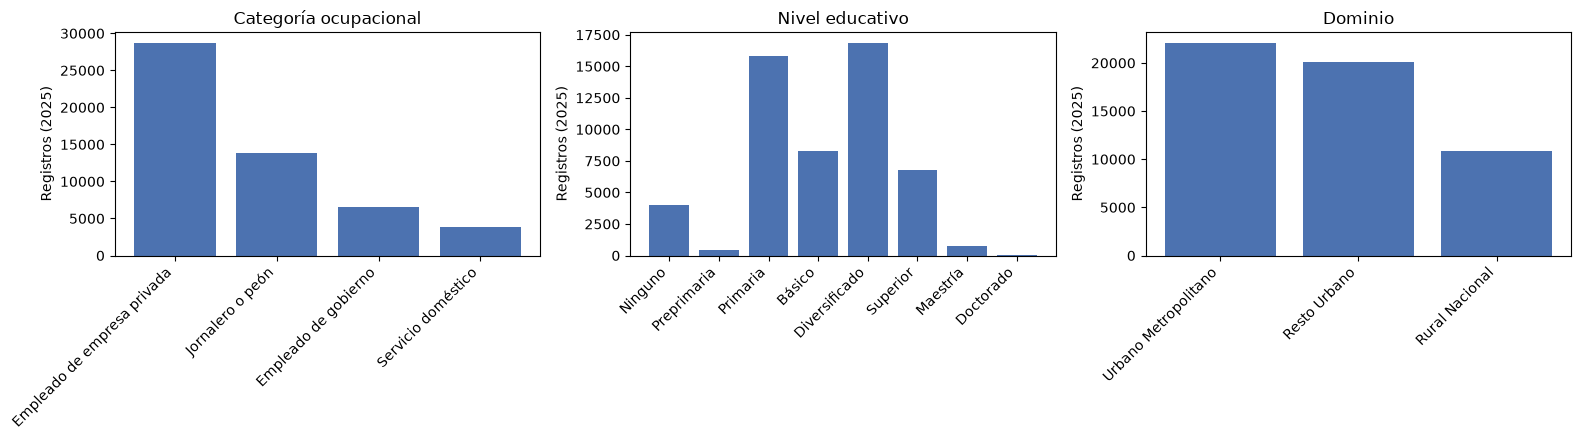

Categoría ocupacional:


,etiqueta,count
2,Empleado de empresa privada,28702
1,Jornalero o peón,13842
0,Empleado de gobierno,6575
3,Servicio doméstico,3906


Nivel educativo:


,etiqueta,count
3,Ninguno,3995
0,Preprimaria,459
6,Primaria,15822
2,Básico,8249
7,Diversificado,16851
1,Superior,6818
4,Maestría,771
5,Doctorado,60


Dominio:


,etiqueta,count
0,Urbano Metropolitano,22072
2,Resto Urbano,20146
1,Rural Nacional,10807


In [30]:
def conteo_categoria(df, columna, etiquetas, orden=None):
    t = (df.groupBy(columna).count().toPandas()
         .assign(etiqueta=lambda d: d[columna].map(etiquetas).fillna(d[columna]))
         .sort_values("count", ascending=False))
    if orden is not None:
        t["etiqueta"] = pd.Categorical(t["etiqueta"], categories=orden, ordered=True)
        t = t.sort_values("etiqueta")
    return t


cat_ocupacional = conteo_categoria(train, "categoria_ocupacional", ETIQUETAS_CATEGORIA_OCUPACIONAL)
cat_educativo    = conteo_categoria(train, "nivel_educativo", ETIQUETAS_NIVEL_EDUCATIVO,
                                     orden=[ETIQUETAS_NIVEL_EDUCATIVO[k] for k in
                                            ["0","1","2","3","4","5","6","7","DESCONOCIDO"]])
cat_dominio      = conteo_categoria(train, "dominio", ETIQUETAS_DOMINIO)

fig, axes = plt.subplots(1, 3, figsize=(16, 4.5))
for ax, tabla, titulo in zip(
    axes,
    [cat_ocupacional, cat_educativo, cat_dominio],
    ["Categoría ocupacional", "Nivel educativo", "Dominio"],
):
    ax.bar(tabla["etiqueta"], tabla["count"], color="#4C72B0")
    ax.set_title(titulo)
    ax.set_ylabel("Registros (2025)")
    ax.tick_params(axis="x", rotation=45)
    for lbl in ax.get_xticklabels():
        lbl.set_ha("right")
plt.tight_layout()
plt.show()

print("Categoría ocupacional:"); display(cat_ocupacional[["etiqueta", "count"]])
print("Nivel educativo:");       display(cat_educativo[["etiqueta", "count"]])
print("Dominio:");                display(cat_dominio[["etiqueta", "count"]])


**¿Cómo se distribuyen los registros entre categorías ocupacionales, niveles educativos y dominios?**

La mayoría de las personas asalariadas trabaja en empresa privada (28,702 registros, poco más de la mitad del total), seguidas por jornaleros o peones (13,842); empleados de gobierno (6,575) y servicio doméstico (3,906) son las categorías minoritarias. En nivel educativo, la mayor concentración está en diversificado (16,851) y primaria (15,822), mientras que maestría (771) y doctorado (60) son casos poco frecuentes. Por dominio, el Urbano Metropolitano (22,072) y el Resto Urbano (20,146) concentran la mayoría de los registros, y el Rural Nacional (10,807) es el de menor tamaño.

## 3. Distribución del salario: ¿simétrica o asimétrica?

Se grafica el histograma del `salario_mensual` en escala original (quetzales) y en escala logarítmica, y se calcula el coeficiente de asimetría (`skewness`) con Spark. La escala logarítmica se usa **solo para visualizar**; el objetivo se mantiene en quetzales para el modelado, como indica el enunciado.

Coeficiente de asimetría (skewness) del salario_mensual en 2025: 5.997


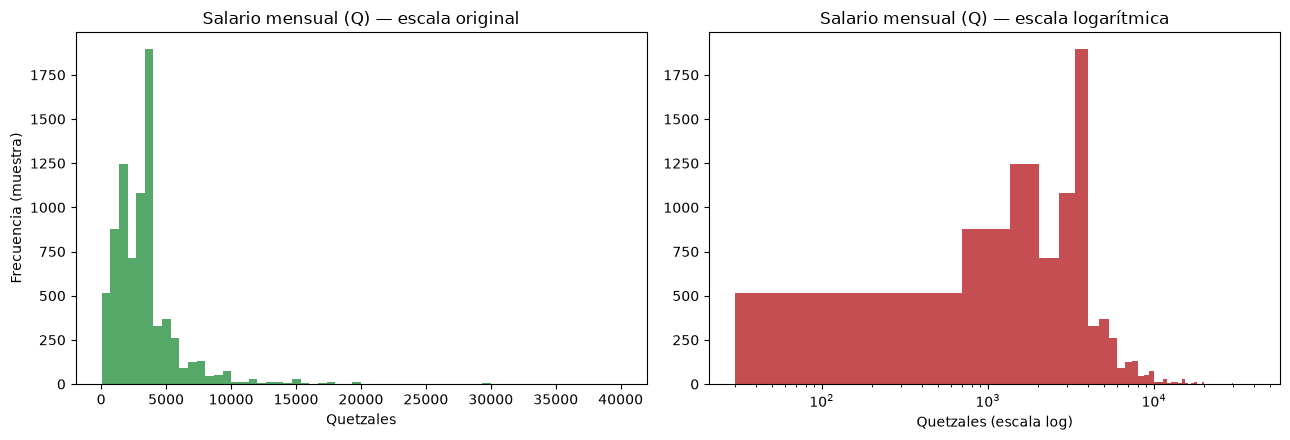

In [31]:
asimetria = train.agg(F.skewness("salario_mensual").alias("skewness")).collect()[0]["skewness"]
print(f"Coeficiente de asimetría (skewness) del salario_mensual en 2025: {asimetria:.3f}")

# Solo para graficar: muestra aleatoria acotada (el skewness y la tabla anteriores ya se calcularon
# sobre el conjunto completo con Spark). No se usa para ninguna métrica.
muestra_salario = (train.select("salario_mensual")
                    .sample(withReplacement=False, fraction=min(1.0, 8000 / n_train), seed=42)
                    .toPandas()["salario_mensual"])

fig, axes = plt.subplots(1, 2, figsize=(13, 4.5))
axes[0].hist(muestra_salario, bins=60, color="#55A868")
axes[0].set_title("Salario mensual (Q) — escala original")
axes[0].set_xlabel("Quetzales")
axes[0].set_ylabel("Frecuencia (muestra)")

axes[1].hist(muestra_salario, bins=60, color="#C44E52")
axes[1].set_xscale("log")
axes[1].set_title("Salario mensual (Q) — escala logarítmica")
axes[1].set_xlabel("Quetzales (escala log)")
plt.tight_layout()
plt.show()


**¿El salario presenta una distribución simétrica o asimétrica? ¿Qué diferencia existe entre su media y su mediana?**

El coeficiente de asimetría obtenido es 5.997, muy alejado de cero, lo que confirma una distribución fuertemente asimétrica hacia la derecha: la mayoría de las personas gana montos moderados, pero existen salarios muy altos que estiran la distribución. Esto es consistente con que la media (Q3,421.68) sea mayor que la mediana (Q3,000): esos salarios extremos elevan el promedio sin representar el caso típico, que la mediana refleja mejor.

## 4. Salario mediano por nivel educativo y por categoría ocupacional

La mediana por grupo se calcula con `percentile_approx(salario_mensual, 0.5)` de Spark SQL sobre el conjunto completo (no sobre una muestra).

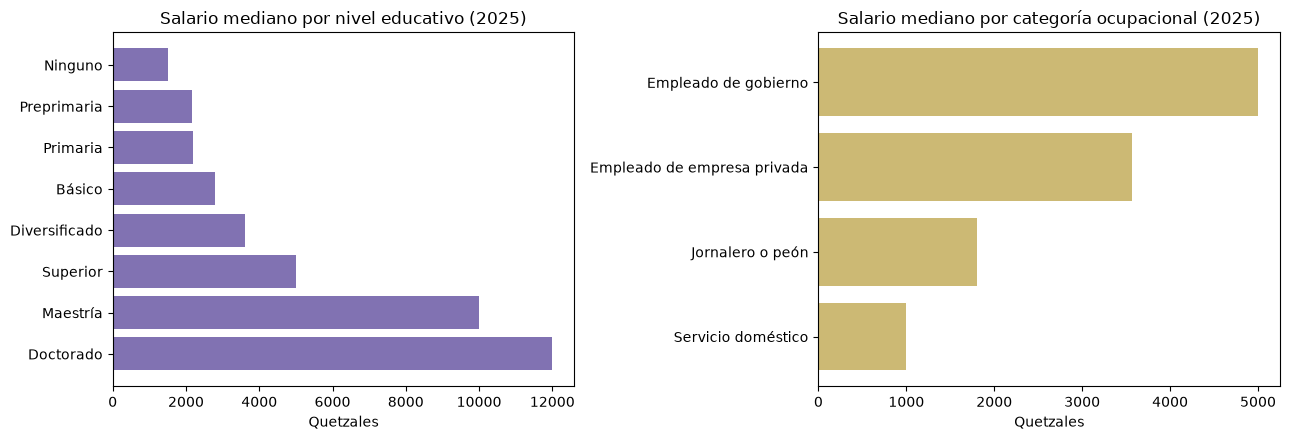

Nivel educativo:


,etiqueta,n,salario_mediano
3,Ninguno,3995,1500.0
0,Preprimaria,459,2160.0
6,Primaria,15822,2200.0
2,Básico,8249,2800.0
7,Diversificado,16851,3600.0
1,Superior,6818,5000.0
4,Maestría,771,10000.0
5,Doctorado,60,12000.0


Categoría ocupacional:


,etiqueta,n,salario_mediano
0,Empleado de gobierno,6575,5000.0
2,Empleado de empresa privada,28702,3565.0
1,Jornalero o peón,13842,1800.0
3,Servicio doméstico,3906,1000.0


In [32]:
def mediana_por_grupo(df, columna, etiquetas, orden=None):
    t = (df.groupBy(columna)
         .agg(F.expr("percentile_approx(salario_mensual, 0.5, 1000000)").alias("salario_mediano"),
              F.count("*").alias("n"))
         .toPandas()
         .assign(etiqueta=lambda d: d[columna].map(etiquetas).fillna(d[columna]))
         .sort_values("salario_mediano", ascending=False))
    if orden is not None:
        t["etiqueta"] = pd.Categorical(t["etiqueta"], categories=orden, ordered=True)
        t = t.sort_values("etiqueta")
    return t[["etiqueta", "n", "salario_mediano"]]


mediana_educativo = mediana_por_grupo(train, "nivel_educativo", ETIQUETAS_NIVEL_EDUCATIVO,
                                       orden=[ETIQUETAS_NIVEL_EDUCATIVO[k] for k in
                                              ["0","1","2","3","4","5","6","7","DESCONOCIDO"]])
mediana_ocupacional = mediana_por_grupo(train, "categoria_ocupacional", ETIQUETAS_CATEGORIA_OCUPACIONAL)

fig, axes = plt.subplots(1, 2, figsize=(13, 4.5))
axes[0].barh(mediana_educativo["etiqueta"], mediana_educativo["salario_mediano"], color="#8172B2")
axes[0].set_title("Salario mediano por nivel educativo (2025)")
axes[0].set_xlabel("Quetzales")
axes[0].invert_yaxis()

axes[1].barh(mediana_ocupacional["etiqueta"], mediana_ocupacional["salario_mediano"], color="#CCB974")
axes[1].set_title("Salario mediano por categoría ocupacional (2025)")
axes[1].set_xlabel("Quetzales")
axes[1].invert_yaxis()
plt.tight_layout()
plt.show()

print("Nivel educativo:");     display(mediana_educativo)
print("Categoría ocupacional:"); display(mediana_ocupacional)


**¿Cómo varía el salario mediano entre niveles educativos y categorías ocupacionales?**

El salario mediano crece de forma prácticamente monotónica con el nivel educativo: desde Q1,500 sin educación hasta Q12,000 con doctorado, pasando por Q2,200 en primaria, Q3,600 en diversificado y Q5,000 en superior. Por categoría ocupacional, los empleados de gobierno tienen la mediana más alta (Q5,000), seguidos por empleados de empresa privada (Q3,565); jornaleros o peones (Q1,800) y sobre todo servicio doméstico (Q1,000) tienen las medianas más bajas. Ningún grupo tiene tan pocos registros como para desconfiar de su mediana.

## 5. Tamaño de la muestra analítica y salario mediano por trimestre

Se compara, para cada uno de los cuatro trimestres de 2025, cuántos registros quedaron en la población analítica y cuál fue su salario mediano.

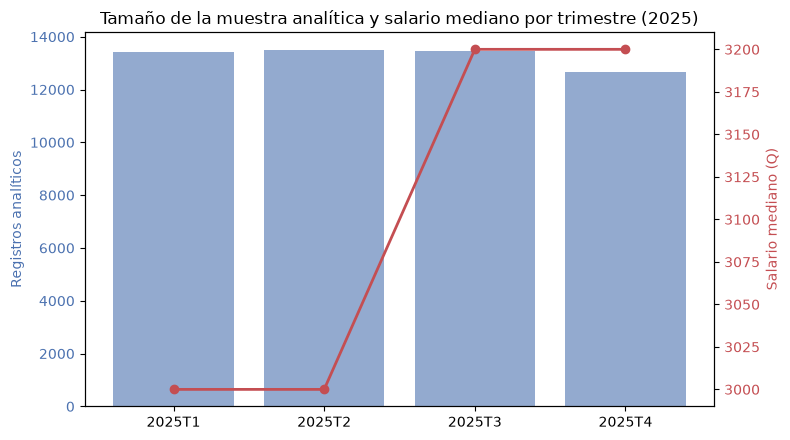

,n_registros,salario_mediano
periodo_archivo,,
2025T1,13419,3000.0
2025T2,13492,3000.0
2025T3,13450,3200.0
2025T4,12664,3200.0


In [33]:
por_trimestre = (train.groupBy("periodo_archivo")
                  .agg(F.count("*").alias("n_registros"),
                       F.expr("percentile_approx(salario_mensual, 0.5, 1000000)").alias("salario_mediano"))
                  .toPandas()
                  .set_index("periodo_archivo")
                  .reindex(PERIODOS_TRAIN_ORDEN))

fig, ax1 = plt.subplots(figsize=(8, 4.5))
ax1.bar(por_trimestre.index, por_trimestre["n_registros"], color="#4C72B0", alpha=0.6, label="Registros")
ax1.set_ylabel("Registros analíticos", color="#4C72B0")
ax1.tick_params(axis="y", labelcolor="#4C72B0")

ax2 = ax1.twinx()
ax2.plot(por_trimestre.index, por_trimestre["salario_mediano"], color="#C44E52",
         marker="o", linewidth=2, label="Salario mediano")
ax2.set_ylabel("Salario mediano (Q)", color="#C44E52")
ax2.tick_params(axis="y", labelcolor="#C44E52")

plt.title("Tamaño de la muestra analítica y salario mediano por trimestre (2025)")
plt.tight_layout()
plt.show()

display(por_trimestre)


**¿Cómo cambian el tamaño de la muestra analítica y el salario mediano entre trimestres?**

El tamaño de la muestra analítica se mantiene relativamente estable entre trimestres (entre 12,664 y 13,492 registros), con una leve caída en el IV de 2025 a pesar de que ese archivo tenía más columnas originales; es decir, la diferencia de estructura del archivo no afectó de forma notoria cuántas personas cumplieron los filtros. El salario mediano también es estable: Q3,000 en el I y II trimestre, y sube ligeramente a Q3,200 en el III y IV trimestre. No se observa ningún trimestre atípico.

## 6. Correlaciones de Pearson entre variables numéricas

Se ensamblan `salario_mensual`, `edad`, `antiguedad` y `horas_semanales` en un vector con `VectorAssembler` y se calcula la matriz de correlación de Pearson con `Correlation.corr()` de `pyspark.ml.stat`, sobre **todos los registros elegibles de 2025** (el `train` completo, sin muestrear).

In [34]:
COLUMNAS_CORR = ["salario_mensual", "edad", "antiguedad", "horas_semanales"]

ensamblador = VectorAssembler(inputCols=COLUMNAS_CORR, outputCol="features_corr")
vector_df = ensamblador.transform(train.select(*COLUMNAS_CORR)).select("features_corr")

matriz_corr = Correlation.corr(vector_df, "features_corr", method="pearson").head()[0]
matriz_corr_np = matriz_corr.toArray()

corr_df = pd.DataFrame(matriz_corr_np, index=COLUMNAS_CORR, columns=COLUMNAS_CORR).round(3)
print("Matriz de correlación de Pearson (población analítica de 2025):")
display(corr_df)


Matriz de correlación de Pearson (población analítica de 2025):


26/09/24 22:31:47 WARN InstanceBuilder: Failed to load implementation from:dev.ludovic.netlib.blas.JNIBLAS
26/09/24 22:31:47 WARN InstanceBuilder: Failed to load implementation from:dev.ludovic.netlib.blas.VectorBLAS


,salario_mensual,edad,antiguedad,horas_semanales
salario_mensual,1.000,0.147,0.180,0.076
edad,0.147,1.000,0.487,-0.105
antiguedad,0.180,0.487,1.000,-0.062
horas_semanales,0.076,-0.105,-0.062,1.000


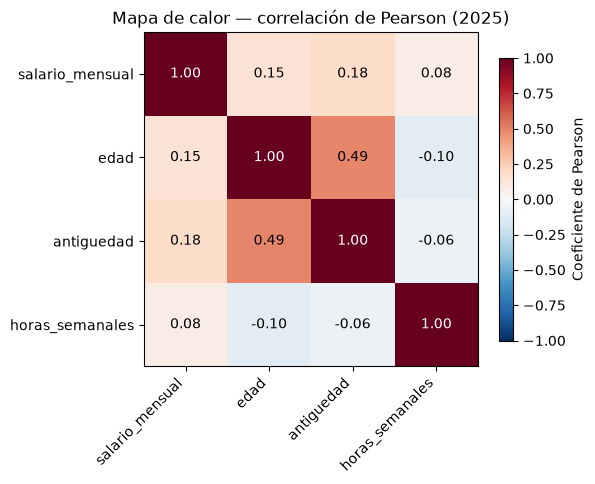

In [35]:
fig, ax = plt.subplots(figsize=(6, 5))
im = ax.imshow(corr_df.values, cmap="RdBu_r", vmin=-1, vmax=1)
ax.set_xticks(range(len(COLUMNAS_CORR)))
ax.set_yticks(range(len(COLUMNAS_CORR)))
ax.set_xticklabels(COLUMNAS_CORR, rotation=45, ha="right")
ax.set_yticklabels(COLUMNAS_CORR)
for i in range(len(COLUMNAS_CORR)):
    for j in range(len(COLUMNAS_CORR)):
        ax.text(j, i, f"{corr_df.values[i, j]:.2f}", ha="center", va="center",
                color="white" if abs(corr_df.values[i, j]) > 0.5 else "black")
ax.set_title("Mapa de calor — correlación de Pearson (2025)")
fig.colorbar(im, ax=ax, shrink=0.8, label="Coeficiente de Pearson")
plt.tight_layout()
plt.show()


**¿Qué variables presentan mayor asociación lineal con el salario? ¿Existe relación entre edad y antigüedad?**

De las tres variables, la antigüedad es la que tiene mayor asociación lineal con el salario (0.180), seguida de la edad (0.147); las horas semanales prácticamente no se relacionan linealmente con el salario (0.076). En los tres casos la asociación es débil, lo que indica que el salario depende de otros factores además de estos. Sí existe una relación moderada entre edad y antigüedad (0.487): las personas de mayor edad tienden a llevar más tiempo en su empleo actual, aunque la relación no es determinística porque la antigüedad es específica del empleo actual y no de toda la vida laboral. Como es esperable, correlación no implica causalidad y Pearson solo capta asociación lineal.

## Parte 3. Segmentación de perfiles mediante KMeans

**Herramientas:** `pyspark.ml.feature` (StringIndexer, OneHotEncoder, VectorAssembler, StandardScaler), `pyspark.ml.clustering.KMeans`, `pyspark.ml.evaluation.ClusteringEvaluator`.
**Entrada:** el DataFrame `train` (población analítica de 2025) ya cargado y cacheado en la Parte 2. No se vuelve a leer el Parquet.

En esta parte se hace lo siguiente:

1. Definir las variables de segmentación y construir dos variantes de vector de características (sin y con `salario_mensual`), ambas estandarizadas.
2. Ajustar KMeans para K = 2, 3, 4 y 5 en ambas variantes, evaluando con el coeficiente de silueta (`ClusteringEvaluator`) y el costo intra-cluster (`trainingCost`, para un análisis tipo codo).
3. Decidir si conviene incluir el salario como variable de segmentación y elegir el mejor K.
4. Ajustar el modelo final, construir el perfil de cada cluster (variables numéricas, categorías dominantes y salario mediano) y describir cada segmento.

El clustering se calcula sobre **todos los registros elegibles de 2025** (`train` completo, sin ponderar por `FACTOR`, como indica el enunciado).

## 1. Variables de segmentación y por qué se evalúa el salario aparte

**¿Vale la pena incluir el salario como variable de segmentación?**

Hay un argumento de diseño en contra, además del empírico que se revisa más abajo con silueta y costo intra-cluster:

- `salario_mensual` es la variable objetivo del laboratorio (la que después se busca explicar/predecir con `edad`, `antiguedad`, `horas_semanales`, `nivel_educativo`, `categoria_ocupacional` y `dominio`). Si el salario se usa **también** para formar los clusters, los segmentos quedarían definidos en parte por la propia variable que luego se querría explicar con ellos, lo que vuelve circular cualquier análisis posterior que relacione "cluster" con "salario" (el cluster ya *sería*, parcialmente, una discretización del salario).
- Es más informativo formar los perfiles únicamente a partir de variables demográficas y laborales **independientes** del salario (edad, antigüedad, horas, nivel educativo, categoría ocupacional, dominio) y luego, como validación externa, observar si esos perfiles —formados sin ver el salario— igual terminan teniendo salarios medianos distintos. Eso sí sería evidencia de que el perfil "explica" algo del salario, en vez de una tautología.

Por eso abajo se ajustan **ambas variantes** (sin y con salario) para los mismos valores de K, se comparan con silueta y costo, y se documenta la decisión final antes de describir los clusters.

In [36]:
from pyspark.ml import Pipeline
from pyspark.ml.feature import StringIndexer, OneHotEncoder, VectorAssembler, StandardScaler
from pyspark.ml.clustering import KMeans
from pyspark.ml.evaluation import ClusteringEvaluator
from pyspark.sql import Window

VARIABLES_CATEGORICAS = ["nivel_educativo", "categoria_ocupacional", "dominio"]
VARIABLES_NUMERICAS_BASE = ["edad", "antiguedad", "horas_semanales"]

train_cl = (train.select(*VARIABLES_NUMERICAS_BASE, *VARIABLES_CATEGORICAS, "salario_mensual",
                          "periodo_archivo")
            .withColumn("id_fila", F.monotonically_increasing_id())
            .cache())
print(f"Registros usados para el clustering: {train_cl.count():,}")


def construir_pipeline(incluir_salario: bool) -> Pipeline:
    # Categóricas -> índice -> one-hot. Numéricas (+ salario opcional) -> vector -> estandarización
    # (media 0, desviación 1). Se combinan al final en una sola columna "features".
    indices = [StringIndexer(inputCol=c, outputCol=f"{c}_idx", handleInvalid="keep")
               for c in VARIABLES_CATEGORICAS]
    ohe = OneHotEncoder(inputCols=[f"{c}_idx" for c in VARIABLES_CATEGORICAS],
                         outputCols=[f"{c}_ohe" for c in VARIABLES_CATEGORICAS])
    numericas = VARIABLES_NUMERICAS_BASE + (["salario_mensual"] if incluir_salario else [])
    ensamblador_num = VectorAssembler(inputCols=numericas, outputCol="num_vec")
    escalador = StandardScaler(inputCol="num_vec", outputCol="num_esc", withMean=True, withStd=True)
    ensamblador_final = VectorAssembler(inputCols=["num_esc"] + [f"{c}_ohe" for c in VARIABLES_CATEGORICAS],
                                         outputCol="features")
    return Pipeline(stages=indices + [ohe, ensamblador_num, escalador, ensamblador_final])


pipeline_sin_salario = construir_pipeline(incluir_salario=False)
pipeline_con_salario = construir_pipeline(incluir_salario=True)

df_sin_salario = pipeline_sin_salario.fit(train_cl).transform(train_cl).select("id_fila", "features").cache()
df_con_salario = pipeline_con_salario.fit(train_cl).transform(train_cl).select("id_fila", "features").cache()
print("Vectores de características listos (sin y con salario).")


Registros usados para el clustering: 53,025
Vectores de características listos (sin y con salario).


## 2. Barrido de K (2, 3, 4 y 5) en ambas variantes

Para cada variante (sin/con salario) y cada K se ajusta KMeans y se calculan:

- **Silueta** (`ClusteringEvaluator`, distancia euclidiana al cuadrado): mide qué tan bien separado y compacto queda cada cluster; va de -1 a 1, más alto es mejor.
- **Costo intra-cluster** (`trainingCost`, suma de distancias al cuadrado a los centroides): baja siempre al aumentar K, se usa para un análisis de codo, no como criterio único.

In [37]:
def barrer_k(df_features, etiqueta_variante, valores_k=(2, 3, 4, 5), semilla=42):
    filas = []
    evaluador = ClusteringEvaluator(featuresCol="features", predictionCol="cluster",
                                     metricName="silhouette", distanceMeasure="squaredEuclidean")
    for k in valores_k:
        kmeans = KMeans(featuresCol="features", predictionCol="cluster", k=k, seed=semilla)
        modelo = kmeans.fit(df_features)
        pred = modelo.transform(df_features)
        silueta = evaluador.evaluate(pred)
        costo = modelo.summary.trainingCost
        filas.append({"variante": etiqueta_variante, "k": k, "silueta": silueta, "costo_intra_cluster": costo})
        print(f"[{etiqueta_variante}] k={k}: silueta={silueta:.4f} | costo intra-cluster={costo:,.1f}")
    return pd.DataFrame(filas)


resultados_sin = barrer_k(df_sin_salario, "sin_salario")
resultados_con = barrer_k(df_con_salario, "con_salario")
resultados_k = pd.concat([resultados_sin, resultados_con], ignore_index=True)
display(resultados_k)


[sin_salario] k=2: silueta=0.3928 | costo intra-cluster=212,809.3
[sin_salario] k=3: silueta=0.2562 | costo intra-cluster=189,306.6
[sin_salario] k=4: silueta=0.2657 | costo intra-cluster=169,638.7
[sin_salario] k=5: silueta=0.2550 | costo intra-cluster=155,322.9
[con_salario] k=2: silueta=0.3962 | costo intra-cluster=263,314.4
[con_salario] k=3: silueta=0.2093 | costo intra-cluster=239,120.6
[con_salario] k=4: silueta=0.2182 | costo intra-cluster=216,979.0
[con_salario] k=5: silueta=0.2487 | costo intra-cluster=198,005.3


,variante,k,silueta,costo_intra_cluster
0,sin_salario,2,0.392757,212809.324299
1,sin_salario,3,0.256211,189306.648041
2,sin_salario,4,0.265697,169638.656170
3,sin_salario,5,0.255046,155322.929756
4,con_salario,2,0.396178,263314.444212
5,con_salario,3,0.209297,239120.584571
6,con_salario,4,0.218207,216978.963331
7,con_salario,5,0.248690,198005.328194


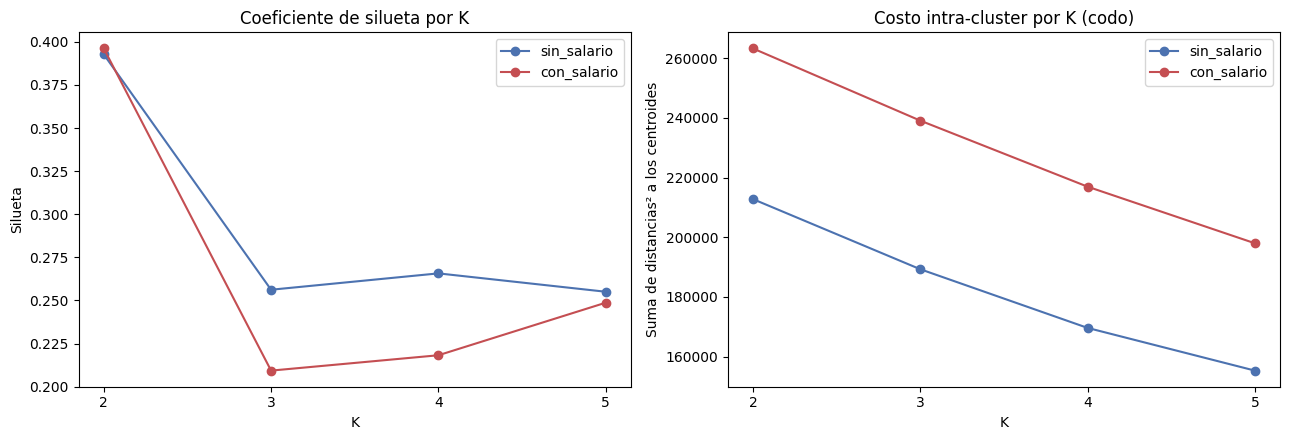

In [38]:
fig, axes = plt.subplots(1, 2, figsize=(13, 4.5))
for variante, color in [("sin_salario", "#4C72B0"), ("con_salario", "#C44E52")]:
    sub = resultados_k[resultados_k["variante"] == variante]
    axes[0].plot(sub["k"], sub["silueta"], marker="o", label=variante, color=color)
    axes[1].plot(sub["k"], sub["costo_intra_cluster"], marker="o", label=variante, color=color)

axes[0].set_title("Coeficiente de silueta por K")
axes[0].set_xlabel("K"); axes[0].set_ylabel("Silueta"); axes[0].set_xticks([2, 3, 4, 5]); axes[0].legend()

axes[1].set_title("Costo intra-cluster por K (codo)")
axes[1].set_xlabel("K"); axes[1].set_ylabel("Suma de distancias² a los centroides")
axes[1].set_xticks([2, 3, 4, 5]); axes[1].legend()

plt.tight_layout()
plt.show()


**Decisión: ¿incluir el salario en la segmentación, y con qué K?**

**¿Incluir el salario?** La evidencia empírica confirma el argumento conceptual de la sección 1: para K=3, 4 y 5, la silueta de `sin_salario` es sistemáticamente mayor que la de `con_salario` (K=3: 0.256 vs. 0.209; K=4: 0.266 vs. 0.218; K=5: 0.255 vs. 0.249). Solo en K=2 `con_salario` gana, y por un margen mínimo (0.396 vs. 0.393). Es decir, agregar el salario como variable de segmentación no solo es conceptualmente cuestionable (circularidad con la variable objetivo), sino que además produce clusters *peor separados* en casi todos los K evaluados. Se elige **`sin_salario`**.

**¿Qué K?** Dentro de la variante `sin_salario`, la silueta no es monótona en K: K=2 da la silueta más alta (0.393), pero es una segmentación muy gruesa (solo dos grupos). Entre las segmentaciones más finas (K=3, 4, 5) — más útiles para describir perfiles distintos — **K=4 tiene la silueta más alta (0.266)**, superando tanto a K=3 (0.256) como a K=5 (0.255). La curva de codo del costo intra-cluster no muestra un quiebre abrupto (baja de forma bastante gradual: -23,503 de K2 a K3, -19,668 de K3 a K4, -14,316 de K4 a K5), así que no contradice la elección: en K=4 todavía se gana una reducción de costo apreciable respecto a K=3, mientras que el salto a K=5 aporta menos. Se elige **K = 4**, ya configurado en la celda siguiente.

In [39]:

INCLUIR_SALARIO_EN_CLUSTERING = False   # True o False
K_ELEGIDO = 4                            # 2, 3, 4 o 5

df_final = df_con_salario if INCLUIR_SALARIO_EN_CLUSTERING else df_sin_salario
etiqueta_variante_final = "con_salario" if INCLUIR_SALARIO_EN_CLUSTERING else "sin_salario"
print(f"Variante elegida: {etiqueta_variante_final} | K = {K_ELEGIDO}")


Variante elegida: sin_salario | K = 4


## 3. Modelo final y asignación de clusters

In [40]:
kmeans_final = KMeans(featuresCol="features", predictionCol="cluster", k=K_ELEGIDO, seed=42)
modelo_final = kmeans_final.fit(df_final)

evaluador = ClusteringEvaluator(featuresCol="features", predictionCol="cluster",
                                 metricName="silhouette", distanceMeasure="squaredEuclidean")
pred_final = modelo_final.transform(df_final)
silueta_final = evaluador.evaluate(pred_final)
print(f"Silueta del modelo final ({etiqueta_variante_final}, K={K_ELEGIDO}): {silueta_final:.4f}")

train_clusters = (train_cl.join(pred_final.select("id_fila", "cluster"), on="id_fila")
                   .drop("id_fila").cache())

train_clusters.groupBy("cluster").count().orderBy("cluster").show()


Silueta del modelo final (sin_salario, K=4): 0.2657
+-------+-----+
|cluster|count|
+-------+-----+
|      0| 9387|
|      1|12190|
|      2| 7050|
|      3|24398|
+-------+-----+



## 4. Perfil de cada cluster

In [41]:
def moda_por_cluster(df, var):
    # Categoría más frecuente de "var" dentro de cada cluster, y qué porcentaje del cluster representa.
    conteo = df.groupBy("cluster", var).count()
    total_cluster = df.groupBy("cluster").agg(F.count("*").alias("n_cluster"))
    ventana = Window.partitionBy("cluster").orderBy(F.desc("count"))
    top = (conteo.withColumn("rank", F.row_number().over(ventana))
           .filter("rank = 1")
           .join(total_cluster, on="cluster")
           .withColumn("pct", F.round(100 * F.col("count") / F.col("n_cluster"), 1))
           .select("cluster", F.col(var).alias(f"{var}_moda"), "pct"))
    return top.toPandas().set_index("cluster")


n_total = train_clusters.count()

perfil_numerico = (train_clusters.groupBy("cluster")
    .agg(F.count("*").alias("n"),
         F.mean("edad").alias("edad_media"),
         F.expr("percentile_approx(antiguedad, 0.5, 1000000)").alias("antiguedad_mediana"),
         F.mean("horas_semanales").alias("horas_media"),
         F.expr("percentile_approx(salario_mensual, 0.5, 1000000)").alias("salario_mediano"))
    .toPandas().set_index("cluster").sort_index())
perfil_numerico["pct_del_total"] = (100 * perfil_numerico["n"] / n_total).round(1)

moda_educativo    = moda_por_cluster(train_clusters, "nivel_educativo").rename(
    columns={"nivel_educativo_moda": "nivel_educativo_dominante", "pct": "pct_ese_nivel"})
moda_ocupacional  = moda_por_cluster(train_clusters, "categoria_ocupacional").rename(
    columns={"categoria_ocupacional_moda": "categoria_dominante", "pct": "pct_esa_categoria"})
moda_dominio      = moda_por_cluster(train_clusters, "dominio").rename(
    columns={"dominio_moda": "dominio_dominante", "pct": "pct_ese_dominio"})

moda_educativo["nivel_educativo_dominante"] = moda_educativo["nivel_educativo_dominante"].map(
    ETIQUETAS_NIVEL_EDUCATIVO).fillna(moda_educativo["nivel_educativo_dominante"])
moda_ocupacional["categoria_dominante"] = moda_ocupacional["categoria_dominante"].map(
    ETIQUETAS_CATEGORIA_OCUPACIONAL).fillna(moda_ocupacional["categoria_dominante"])
moda_dominio["dominio_dominante"] = moda_dominio["dominio_dominante"].map(
    ETIQUETAS_DOMINIO).fillna(moda_dominio["dominio_dominante"])

perfil = (perfil_numerico
          .join(moda_educativo).join(moda_ocupacional).join(moda_dominio)
          .round(1))
perfil = perfil[["n", "pct_del_total", "edad_media", "antiguedad_mediana", "horas_media",
                  "salario_mediano", "nivel_educativo_dominante", "pct_ese_nivel",
                  "categoria_dominante", "pct_esa_categoria", "dominio_dominante", "pct_ese_dominio"]]
display(perfil)


,n,pct_del_total,edad_media,antiguedad_mediana,horas_media,salario_mediano,nivel_educativo_dominante,pct_ese_nivel,categoria_dominante,pct_esa_categoria,dominio_dominante,pct_ese_dominio
cluster,,,,,,,,,,,,
0,9387,17.7,30.5,2.0,73.9,3000.0,Diversificado,34.6,Empleado de empresa privada,70.4,Resto Urbano,45.3
1,12190,23.0,48.8,2.7,39.1,3000.0,Primaria,40.3,Empleado de empresa privada,42.7,Urbano Metropolitano,46.8
2,7050,13.3,49.7,20.0,40.8,3800.0,Primaria,26.5,Empleado de empresa privada,39.4,Urbano Metropolitano,43.6
3,24398,46.0,26.0,1.3,40.8,3000.0,Diversificado,39.6,Empleado de empresa privada,57.8,Urbano Metropolitano,42.0


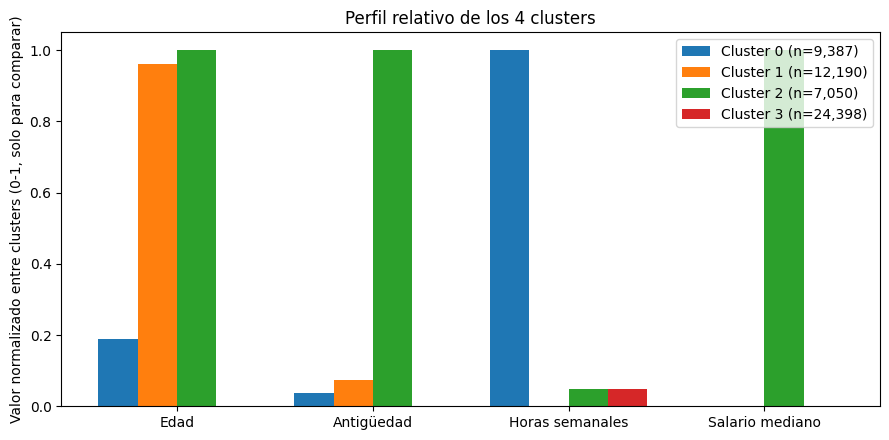

In [42]:

variables_perfil = ["edad_media", "antiguedad_mediana", "horas_media", "salario_mediano"]
normalizado = (perfil[variables_perfil] - perfil[variables_perfil].min()) / (
    perfil[variables_perfil].max() - perfil[variables_perfil].min())

fig, ax = plt.subplots(figsize=(9, 4.5))
x = range(len(variables_perfil))
ancho = 0.8 / K_ELEGIDO
for i, cluster_id in enumerate(perfil.index):
    ax.bar([xi + i * ancho for xi in x], normalizado.loc[cluster_id], width=ancho,
           label=f"Cluster {cluster_id} (n={int(perfil.loc[cluster_id, 'n']):,})")

ax.set_xticks([xi + (K_ELEGIDO - 1) * ancho / 2 for xi in x])
ax.set_xticklabels(["Edad", "Antigüedad", "Horas semanales", "Salario mediano"])
ax.set_ylabel("Valor normalizado entre clusters (0-1, solo para comparar)")
ax.set_title(f"Perfil relativo de los {K_ELEGIDO} clusters")
ax.legend()
plt.tight_layout()
plt.show()


## 5. Descripción de los clusters

In [43]:
for cluster_id, fila in perfil.iterrows():
    print(f"--- Cluster {cluster_id} (n={int(fila['n']):,}, {fila['pct_del_total']}% del total) ---")
    print(f"Edad media: {fila['edad_media']} | Antigüedad mediana: {fila['antiguedad_mediana']} años | "
          f"Horas semanales media: {fila['horas_media']} | Salario mediano: Q{fila['salario_mediano']:,.0f}")
    print(f"Nivel educativo dominante: {fila['nivel_educativo_dominante']} ({fila['pct_ese_nivel']}% del cluster)")
    print(f"Categoría ocupacional dominante: {fila['categoria_dominante']} ({fila['pct_esa_categoria']}% del cluster)")
    print(f"Dominio dominante: {fila['dominio_dominante']} ({fila['pct_ese_dominio']}% del cluster)")
    print()


--- Cluster 0 (n=9,387, 17.7% del total) ---
Edad media: 30.5 | Antigüedad mediana: 2.0 años | Horas semanales media: 73.9 | Salario mediano: Q3,000
Nivel educativo dominante: Diversificado (34.6% del cluster)
Categoría ocupacional dominante: Empleado de empresa privada (70.4% del cluster)
Dominio dominante: Resto Urbano (45.3% del cluster)

--- Cluster 1 (n=12,190, 23.0% del total) ---
Edad media: 48.8 | Antigüedad mediana: 2.7 años | Horas semanales media: 39.1 | Salario mediano: Q3,000
Nivel educativo dominante: Primaria (40.3% del cluster)
Categoría ocupacional dominante: Empleado de empresa privada (42.7% del cluster)
Dominio dominante: Urbano Metropolitano (46.8% del cluster)

--- Cluster 2 (n=7,050, 13.3% del total) ---
Edad media: 49.7 | Antigüedad mediana: 20.0 años | Horas semanales media: 40.8 | Salario mediano: Q3,800
Nivel educativo dominante: Primaria (26.5% del cluster)
Categoría ocupacional dominante: Empleado de empresa privada (39.4% del cluster)
Dominio dominante: Ur

**Descripción de los perfiles (K = 4, segmentación sin salario):**

- **Cluster 0 — Jornadas largas en el sector privado** (9,387 registros, 17.7%). Personas jóvenes (30.5 años en promedio), con poca antigüedad (2 años) y una carga horaria muy por encima del resto (73.9 horas semanales, casi el doble que los demás clusters), concentradas en empresa privada (70.4%). Su salario mediano es el mismo que el de la mayoría (Q3,000), pero trabajando casi el doble de horas: es el grupo con menor salario por hora de los cuatro.
- **Cluster 1 — Adultos con baja escolaridad y jornada corta** (12,190 registros, 23.0%). El de mayor edad junto con el cluster 2 (48.8 años), con predominio de primaria (40.3%) y la jornada más corta (39.1 horas). Con poca antigüedad (2.7 años) alcanza el mismo salario mediano que el cluster 0 (Q3,000) trabajando casi la mitad de horas.
- **Cluster 2 — Trabajadores veteranos, el mejor pagado** (7,050 registros, 13.3%). El más pequeño de los cuatro y el de mayor antigüedad por lejos: 20 años de mediana, diez veces más que cualquier otro cluster. Edad media de 49.7 años y jornada estándar (40.8 horas). Es el único con salario mediano por encima del resto (Q3,800 frente a Q3,000), lo que apunta a la antigüedad acumulada —más que al nivel educativo o a la categoría ocupacional, ambos mixtos en este grupo— como el rasgo asociado a su mejor salario.
- **Cluster 3 — Jóvenes recién ingresados** (24,398 registros, 46.0%). El más grande y el más joven (26.0 años), con la antigüedad más corta (1.3 años), jornada estándar (40.8 horas) y predominio de empresa privada (57.8%) con educación diversificada. Su salario mediano (Q3,000) es el típico de la población analítica: el perfil de entrada al trabajo asalariado.

Los cuatro perfiles se formaron **sin usar el salario** y aun así terminan con salarios medianos distintos (Q3,800 en el cluster 2 frente a Q3,000 en los demás), lo que respalda la decisión tomada en la sección 2. Son diferencias descriptivas entre los registros analizados: no implican causalidad ni deben leerse como cuánto debería ganar una persona.

## Parte 4. Modelado supervisado: regresión lineal y Random Forest

**Herramientas:** `pyspark.ml` (`Pipeline`, `StringIndexer`, `OneHotEncoder`, `VectorAssembler`), `pyspark.ml.regression` (`LinearRegression`, `RandomForestRegressor`) y `pyspark.ml.evaluation.RegressionEvaluator`.
**Entrada:** los DataFrames `train` (2025) y `test` (2026T1) ya cargados y cacheados en la Parte 2. No se vuelve a leer el Parquet.

La tarea es estimar `salario_mensual` a partir de **exactamente seis predictores**: `edad`, `antiguedad`, `horas_semanales`, `nivel_educativo`, `categoria_ocupacional` y `dominio`. Es una predicción del salario del período observado, no un pronóstico del salario futuro de una persona. No se usan identificadores, el factor de expansión, otros montos de ingresos, el salario por hora derivado del objetivo ni la etiqueta de cluster de la Parte 3.

En esta parte se hace lo siguiente:

1. Partir el conjunto de 2025 en entrenamiento (I, II y III de 2025) y validación (IV de 2025), como indica el enunciado.
2. Construir un modelo de referencia (predecir siempre la media del salario de entrenamiento) para tener contra qué comparar.
3. Ajustar el pipeline de regresión lineal con varias configuraciones de regularización y quedarse con la de menor RMSE de validación.
4. Ajustar el pipeline de Random Forest variando el número de árboles y la profundidad máxima, con semilla fija, y quedarse con la de menor RMSE de validación.
5. Comparar ambos algoritmos entre sí y contra la referencia, y guardar el mejor modelo de cada uno.

Todos los componentes de los pipelines (índices, codificación, escalado y modelo) se ajustan **exclusivamente con los datos de entrenamiento**; la validación solo se transforma. El primer trimestre de 2026 no se toca aquí: queda reservado para la Parte 5.

## 0. Partición de desarrollo: entrenamiento y validación

El enunciado asigna los archivos de I, II y III de 2025 a desarrollo y entrenamiento, y el de IV de 2025 a **validación y posterior entrenamiento final**. Esa es la partición que se usa aquí, y es una partición **temporal**, no aleatoria: por el diseño longitudinal con rotación de la ENEIC, una misma persona puede aparecer en dos trimestres, así que una división aleatoria de 2025 pondría observaciones de la misma persona a ambos lados y produciría una validación optimista (fuga de información). Separando por trimestre, validar en IV de 2025 se parece a lo que después se hará con 2026: aplicar el modelo a un corte posterior.

In [ ]:
from pyspark.ml import Pipeline, PipelineModel
from pyspark.ml.feature import StringIndexer, OneHotEncoder, VectorAssembler
from pyspark.ml.regression import LinearRegression, RandomForestRegressor
from pyspark.ml.evaluation import RegressionEvaluator

# Los seis predictores del enunciado, ni uno más.
OBJETIVO                = "salario_mensual"
PREDICTORES_NUMERICOS   = ["edad", "antiguedad", "horas_semanales"]
PREDICTORES_CATEGORICOS = ["nivel_educativo", "categoria_ocupacional", "dominio"]
SEMILLA = 42

PERIODOS_ENTRENAMIENTO = ["2025T1", "2025T2", "2025T3"]
PERIODO_VALIDACION     = "2025T4"

entrenamiento = train.filter(F.col("periodo_archivo").isin(PERIODOS_ENTRENAMIENTO)).cache()
validacion    = train.filter(F.col("periodo_archivo") == PERIODO_VALIDACION).cache()
n_entrenamiento, n_validacion = entrenamiento.count(), validacion.count()
assert n_entrenamiento + n_validacion == n_train, "La partición debe cubrir todo 2025 sin traslapes"

print(f"Entrenamiento (I, II y III de 2025): {n_entrenamiento:,} registros")
print(f"Validación (IV de 2025):             {n_validacion:,} registros")
print(f"Prueba final (I de 2026, reservada): {n_test:,} registros")


## 1. Modelo de referencia

Antes de ajustar cualquier modelo conviene fijar el punto de comparación: un modelo que ignora todos los predictores y responde siempre la **media del salario de entrenamiento**. Cualquier modelo que no le gane no está aportando nada. Su R² sobre validación es aproximadamente cero por construcción (puede quedar levemente negativo, porque la media se calcula en entrenamiento y se aplica a otro trimestre), y su RMSE es esencialmente la desviación estándar del salario en validación.

In [ ]:
def metricas(predicciones, etiqueta, columna_prediccion="prediction"):
    # MAE, RMSE y R² con RegressionEvaluator, siempre sobre el DataFrame completo que se pase.
    def evaluar(nombre_metrica):
        return RegressionEvaluator(labelCol=OBJETIVO, predictionCol=columna_prediccion,
                                   metricName=nombre_metrica).evaluate(predicciones)
    return {"modelo": etiqueta, "MAE": evaluar("mae"), "RMSE": evaluar("rmse"), "R2": evaluar("r2")}


media_entrenamiento = entrenamiento.agg(F.mean(OBJETIVO)).collect()[0][0]
referencia_validacion = validacion.withColumn("prediction", F.lit(media_entrenamiento))
metricas_referencia = metricas(referencia_validacion, "Referencia: media de entrenamiento")

print(f"Media del salario en entrenamiento: Q{media_entrenamiento:,.2f}")
print("Métricas del modelo de referencia sobre validación (IV de 2025):")
display(pd.DataFrame([metricas_referencia]).set_index("modelo").round(4))


## 2. Pipeline de regresión lineal

El pipeline tiene las cuatro etapas que pide el enunciado:

a. `StringIndexer` y `OneHotEncoder` para `nivel_educativo`, `categoria_ocupacional` y `dominio`.
b. `VectorAssembler` para combinar las tres numéricas (`edad`, `antiguedad`, `horas_semanales`) con las categóricas ya codificadas.
c. Estandarización de los predictores mediante la **opción interna** de `LinearRegression` (`standardization=True`). No se agrega además un `StandardScaler`: el enunciado indica que no es necesario aplicar ambos mecanismos.
d. `LinearRegression` para estimar el salario mensual.

Se prueban seis configuraciones de regularización, desde mínimos cuadrados sin penalización hasta Lasso fuerte, y se selecciona la de **menor RMSE de validación**. `regParam` controla la fuerza de la penalización y `elasticNetParam` su tipo: 0 es Ridge (L2), 1 es Lasso (L1) y los valores intermedios combinan ambas.

Cada pipeline se ajusta con `entrenamiento` y se evalúa transformando `validacion`, de modo que ni los índices de categorías ni las medias y desviaciones del escalado ven los datos de validación.

In [ ]:
def etapas_features():
    # a) Índice + one-hot de las tres categóricas. handleInvalid="keep" reserva un nivel extra
    #    para códigos no vistos en entrenamiento (por ejemplo, un DESCONOCIDO que apareciera
    #    solo en validación o en 2026), en vez de fallar o descartar la fila.
    indices = [StringIndexer(inputCol=c, outputCol=f"{c}_idx", handleInvalid="keep")
               for c in PREDICTORES_CATEGORICOS]
    codificador = OneHotEncoder(inputCols=[f"{c}_idx" for c in PREDICTORES_CATEGORICOS],
                                outputCols=[f"{c}_ohe" for c in PREDICTORES_CATEGORICOS])
    # b) Numéricas + categóricas codificadas en una sola columna "features".
    ensamblador = VectorAssembler(
        inputCols=PREDICTORES_NUMERICOS + [f"{c}_ohe" for c in PREDICTORES_CATEGORICOS],
        outputCol="features")
    return indices + [codificador, ensamblador]


def nombres_de_features(modelo_pipeline):
    # Nombres en el mismo orden en que VectorAssembler arma el vector "features", para poder
    # leer coeficientes e importancias. OneHotEncoder descarta la última columna (dropLast),
    # que aquí es el nivel reservado para códigos no vistos: esa es la categoría de referencia.
    nombres = list(PREDICTORES_NUMERICOS)
    indexadores = {etapa.getInputCol(): etapa for etapa in modelo_pipeline.stages
                   if hasattr(etapa, "labels")}
    for c in PREDICTORES_CATEGORICOS:
        nombres += [f"{c}={etiqueta}" for etiqueta in indexadores[c].labels]
    return nombres


CONFIGS_LR = [
    {"regParam": 0.0,  "elasticNetParam": 0.0},   # mínimos cuadrados, sin regularización
    {"regParam": 0.01, "elasticNetParam": 0.0},   # Ridge (L2) muy suave
    {"regParam": 0.1,  "elasticNetParam": 0.0},   # Ridge (L2)
    {"regParam": 1.0,  "elasticNetParam": 0.0},   # Ridge (L2) fuerte
    {"regParam": 0.1,  "elasticNetParam": 0.5},   # Elastic Net (mitad L1, mitad L2)
    {"regParam": 1.0,  "elasticNetParam": 1.0},   # Lasso (L1) fuerte
]

filas_lr, modelos_lr = [], {}
for configuracion in CONFIGS_LR:
    regresion = LinearRegression(featuresCol="features", labelCol=OBJETIVO,
                                 standardization=True, maxIter=100, **configuracion)
    modelo = Pipeline(stages=etapas_features() + [regresion]).fit(entrenamiento)   # solo entrenamiento
    etiqueta = (f"LR regParam={configuracion['regParam']}, "
                f"elasticNetParam={configuracion['elasticNetParam']}")
    fila = metricas(modelo.transform(validacion), etiqueta)
    fila.update(configuracion)
    filas_lr.append(fila)
    modelos_lr[etiqueta] = modelo
    print(f"{etiqueta:<48s} MAE={fila['MAE']:>9,.2f} | RMSE={fila['RMSE']:>9,.2f} | R²={fila['R2']:.4f}")

resultados_lr = pd.DataFrame(filas_lr).set_index("modelo")
mejor_lr_etiqueta = resultados_lr["RMSE"].idxmin()
modelo_lr_validacion = modelos_lr[mejor_lr_etiqueta]

print(f"\nConfiguración con menor RMSE de validación: {mejor_lr_etiqueta}")
print("Comparación contra el modelo de referencia (métricas sobre validación, IV de 2025):")
display(pd.concat([pd.DataFrame([metricas_referencia]).set_index("modelo"),
                   resultados_lr]).round(4))


In [ ]:
# Coeficientes del mejor modelo lineal, con el nombre de cada variable.
regresion_ajustada = modelo_lr_validacion.stages[-1]
coeficientes = pd.DataFrame({
    "variable": nombres_de_features(modelo_lr_validacion),
    "coeficiente_Q": [float(v) for v in regresion_ajustada.coefficients],
}).set_index("variable").round(2)

print(f"Intercepto: Q{regresion_ajustada.intercept:,.2f}")
print("Coeficientes en quetzales (la estandarización es interna: Spark devuelve los")
print("coeficientes ya reexpresados en la escala original de cada variable).")
print("En las categóricas, el nivel de referencia es el reservado a códigos no vistos.")
display(coeficientes)


**¿Qué tan bien estima el salario la regresión lineal frente al modelo de referencia?**

Sobre validación (IV de 2025), la regresión lineal baja el RMSE de Q2,889.57 a Q2,186.42 y el MAE de Q1,672.50 a Q1,210.14, con un R² de 0.4257: los seis predictores explican cerca del 43% de la varianza del salario, frente al ~0% de la referencia. El error típico en valor absoluto baja un 28%. Aun así es un error grande frente a un salario mediano de Q3,000: el modelo distingue bien entre grupos, pero no predice con precisión el salario de una persona concreta, algo esperable porque el salario depende de muchos factores que la encuesta no recoge aquí (ocupación específica, empresa, región exacta, experiencia previa).

**La regularización prácticamente no cambia nada.** Las seis configuraciones dan métricas idénticas hasta el cuarto decimal (RMSE entre 2,186.42 y 2,186.48). Es lo esperable: el vector de características tiene 18 columnas (3 numéricas y 15 indicadoras) y se ajusta con 40,361 registros, así que no hay sobreajuste que penalizar; ni siquiera el Lasso fuerte (`regParam=1.0`, `elasticNetParam=1.0`) mueve los resultados. Gana por diferencias en el cuarto decimal la versión **sin regularización** (`regParam=0.0`), que es la que se usa de aquí en adelante; cualquiera de las otras daría lo mismo en la práctica.

**Los coeficientes son coherentes con la exploración de la Parte 2.** Manteniendo todo lo demás fijo, cada año de edad suma Q20.43, cada año de antigüedad Q23.37 y cada hora semanal Q16.17. Como el nivel de referencia del one-hot es la categoría reservada a códigos no vistos, las comparaciones útiles son entre niveles. Tomando como punto de partida los más frecuentes: frente a diversificado, una maestría suma Q6,781 y un doctorado Q8,620, superior suma Q1,694, y básico, primaria y ninguno restan Q631, Q836 y Q1,333. Frente a empresa privada, gobierno suma Q1,174, jornalero resta Q858 y servicio doméstico resta Q1,665. El dominio pesa poco: Urbano Metropolitano está unos Q560 por encima de los otros dos, que entre sí casi no se distinguen (Q9 de diferencia). El orden reproduce el de los salarios medianos de la Parte 2, y son asociaciones, no efectos causales.

## 3. Pipeline de Random Forest

El pipeline reutiliza exactamente las mismas etapas de preparación (`etapas_features()`): índice, one-hot y ensamblado. La única diferencia es el estimador final, `RandomForestRegressor`, y que aquí **no se estandarizan** los predictores: los árboles parten el espacio con umbrales sobre cada variable por separado, así que reescalarlas no cambia las particiones posibles.

Se prueban siete configuraciones variando número de árboles y profundidad máxima, todas con `seed=42` para que el muestreo bootstrap y la selección de variables sean reproducibles, y se selecciona la de **menor RMSE de validación**. La rejilla incluye profundidad 20 para verificar que el mejor valor no se quedara en el borde del rango explorado.

Este barrido es la parte más lenta del notebook: son siete bosques ajustados sobre ~40 mil registros.

In [ ]:
CONFIGS_RF = [
    {"numTrees": 50,  "maxDepth": 5},
    {"numTrees": 100, "maxDepth": 5},
    {"numTrees": 100, "maxDepth": 10},
    {"numTrees": 200, "maxDepth": 10},
    {"numTrees": 100, "maxDepth": 15},
    {"numTrees": 200, "maxDepth": 15},
    {"numTrees": 200, "maxDepth": 20},
]

filas_rf, modelos_rf = [], {}
for configuracion in CONFIGS_RF:
    bosque = RandomForestRegressor(featuresCol="features", labelCol=OBJETIVO,
                                   seed=SEMILLA, **configuracion)
    modelo = Pipeline(stages=etapas_features() + [bosque]).fit(entrenamiento)   # solo entrenamiento
    etiqueta = f"RF numTrees={configuracion['numTrees']}, maxDepth={configuracion['maxDepth']}"
    fila = metricas(modelo.transform(validacion), etiqueta)
    fila.update(configuracion)
    filas_rf.append(fila)
    modelos_rf[etiqueta] = modelo
    print(f"{etiqueta:<40s} MAE={fila['MAE']:>9,.2f} | RMSE={fila['RMSE']:>9,.2f} | R²={fila['R2']:.4f}")

resultados_rf = pd.DataFrame(filas_rf).set_index("modelo")
mejor_rf_etiqueta = resultados_rf["RMSE"].idxmin()
modelo_rf_validacion = modelos_rf[mejor_rf_etiqueta]

print(f"\nConfiguración con menor RMSE de validación: {mejor_rf_etiqueta}")
print("Comparación de los tres enfoques sobre validación (IV de 2025):")
display(pd.concat([
    pd.DataFrame([metricas_referencia]).set_index("modelo"),
    resultados_lr.loc[[mejor_lr_etiqueta], ["MAE", "RMSE", "R2"]],
    resultados_rf.loc[[mejor_rf_etiqueta], ["MAE", "RMSE", "R2"]],
]).round(4))


In [ ]:
# Importancia de cada variable en el mejor bosque, agregada por variable original
# (la importancia de una categórica es la suma de las de sus columnas one-hot).
importancias = pd.DataFrame({
    "variable": nombres_de_features(modelo_rf_validacion),
    "importancia": [float(v) for v in modelo_rf_validacion.stages[-1].featureImportances.toArray()],
})
importancias["variable_original"] = importancias["variable"].str.split("=").str[0]

por_variable = (importancias.groupby("variable_original")["importancia"].sum()
                .sort_values(ascending=False).to_frame().round(4))
print("Importancia agregada por variable original:")
display(por_variable)

print("Las diez columnas individuales más importantes:")
display(importancias.sort_values("importancia", ascending=False)
        .head(10).set_index("variable")[["importancia"]].round(4))


**¿Cuál de los dos algoritmos obtuvo mejores resultados en validación y qué explica la diferencia?**

Gana el **Random Forest** en las tres métricas. Su mejor configuración (200 árboles, profundidad 20) obtiene sobre validación MAE Q1,026.27, RMSE Q1,893.86 y R² 0.5691, frente a MAE Q1,210.14, RMSE Q2,186.42 y R² 0.4257 de la regresión lineal: un 15% menos de MAE y un 13% menos de RMSE, y sube la varianza explicada de 43% a 57%. Los dos, a su vez, quedan muy por encima de la referencia (RMSE Q2,889.57).

**Lo que manda es la profundidad, no el número de árboles.** Con profundidad 5 el bosque apenas le gana a la regresión lineal (RMSE 2,161.14); al pasar a 10 baja a 1,981.68, a 15 baja a 1,912.46 y a 20 a 1,893.86. Duplicar los árboles con la misma profundidad cambia poco (a profundidad 15, 100 árboles dan 1,920.89 y 200 dan 1,912.46: 0.4% de diferencia). Se incluyó profundidad 20 justamente para comprobar que el mínimo no estuviera en el borde de la rejilla: la mejora de 15 a 20 ya es de apenas 1%, la curva se aplana y seguir profundizando solo agrandaría el modelo y el riesgo de sobreajuste, así que el barrido se detiene ahí.

**Por qué el bosque le gana a la recta.** La regresión lineal es aditiva: obliga a que el efecto de una hora extra de trabajo sea el mismo para un jornalero que para un empleado de gobierno, y a que cada año de edad valga lo mismo a los 20 que a los 60. El Random Forest puede capturar no linealidades (el salario crece con la edad hasta cierto punto y luego se aplana) e interacciones entre variables (la prima por educación superior no es igual en el sector público que en el servicio doméstico) sin que haya que declararlas. Ese es justo el tipo de estructura que se intuía en la Parte 2, donde las correlaciones lineales con el salario eran débiles (0.180 la antigüedad, 0.147 la edad, 0.076 las horas) pese a que los salarios medianos por grupo sí diferían mucho.

**Las importancias confirman la lectura de los coeficientes.** Sumando las columnas one-hot de cada variable original, el nivel educativo concentra el 35% de la importancia y la categoría ocupacional el 25%; edad (12%), horas semanales (12%) y antigüedad (11%) quedan en un segundo plano y el dominio apenas aporta 4%. Es decir: en estos datos, qué tanto estudió una persona y en qué tipo de relación laboral está pesan más que su edad, su jornada o dónde vive.

## 4. Guardado de los mejores modelos de validación

Se guarda el pipeline completo de cada algoritmo (no solo el estimador): así el modelo leído desde disco vuelve a aplicar los mismos índices y la misma codificación a datos nuevos. Para verificar que quedaron bien escritos, se leen de vuelta y se re-evalúan sobre validación.

In [ ]:
DIR_MODELOS = DIR_SALIDA / "modelos"
DIR_MODELOS.mkdir(parents=True, exist_ok=True)

RUTA_LR_VALIDACION = DIR_MODELOS / "lr_mejor_validacion"
RUTA_RF_VALIDACION = DIR_MODELOS / "rf_mejor_validacion"
modelo_lr_validacion.write().overwrite().save(str(RUTA_LR_VALIDACION))
modelo_rf_validacion.write().overwrite().save(str(RUTA_RF_VALIDACION))

# Verificación: se vuelven a leer desde disco y se re-evalúan sobre validación.
for ruta, etiqueta, rmse_esperado in [
    (RUTA_LR_VALIDACION, mejor_lr_etiqueta, resultados_lr.loc[mejor_lr_etiqueta, "RMSE"]),
    (RUTA_RF_VALIDACION, mejor_rf_etiqueta, resultados_rf.loc[mejor_rf_etiqueta, "RMSE"]),
]:
    modelo_leido = PipelineModel.load(str(ruta))
    rmse_leido = RegressionEvaluator(labelCol=OBJETIVO, metricName="rmse").evaluate(
        modelo_leido.transform(validacion))
    print(f"{ruta.name:<22s} [{etiqueta}] RMSE al releer desde disco = {rmse_leido:,.2f}")
    assert abs(rmse_leido - rmse_esperado) < 1e-6


## Parte 5. Entrenamiento final y evaluación en 2026

**Entrada:** las configuraciones elegidas en la Parte 4 y los DataFrames `train` (2025) y `test` (2026T1).

Ya elegida una configuración por algoritmo, se reajustan ambos pipelines con **todo 2025** (entrenamiento + validación, tal como indica el enunciado para el IV de 2025: "validación y posterior entrenamiento final") y se aplican al primer trimestre de 2026, preparado con exactamente las mismas reglas de la Parte 1.

Los dos modelos se evalúan sobre **exactamente los mismos registros** de prueba: se generan las dos predicciones sobre el mismo DataFrame y se verifica que ninguno deje filas sin predecir. El modelo de referencia también se recalcula con la media de todo 2025.

Un detalle de implementación: entre una transformación y otra se descartan las columnas intermedias del pipeline (índices, one-hot y `features`), porque el segundo pipeline necesita crearlas de nuevo y Spark no permite sobrescribir columnas existentes.

## 1. Reajuste con todo 2025 y predicciones sobre 2026

In [ ]:
config_lr_elegida = {clave: float(resultados_lr.loc[mejor_lr_etiqueta, clave])
                     for clave in ("regParam", "elasticNetParam")}
config_rf_elegida = {clave: int(resultados_rf.loc[mejor_rf_etiqueta, clave])
                     for clave in ("numTrees", "maxDepth")}
print("Configuración elegida para la regresión lineal:", config_lr_elegida)
print("Configuración elegida para el Random Forest:   ", config_rf_elegida)

# Reajuste con todo 2025.
modelo_lr_final = Pipeline(stages=etapas_features() + [LinearRegression(
    featuresCol="features", labelCol=OBJETIVO, standardization=True, maxIter=100,
    **config_lr_elegida)]).fit(train)
modelo_rf_final = Pipeline(stages=etapas_features() + [RandomForestRegressor(
    featuresCol="features", labelCol=OBJETIVO, seed=SEMILLA, **config_rf_elegida)]).fit(train)

media_2025 = train.agg(F.mean(OBJETIVO)).collect()[0][0]

# Las dos predicciones sobre los mismos registros de prueba. El residuo se define como
# real - predicho: positivo = el modelo subestimó; negativo = sobreestimó.
columnas_test = test.columns
predicciones_lr = (modelo_lr_final.transform(test)
                   .select(*columnas_test, F.col("prediction").alias("pred_lr")))
predicciones_test = (modelo_rf_final.transform(predicciones_lr)
                     .select(*predicciones_lr.columns, F.col("prediction").alias("pred_rf"))
                     .withColumn("pred_referencia", F.lit(media_2025))
                     .withColumn("residuo_lr", F.col(OBJETIVO) - F.col("pred_lr"))
                     .withColumn("residuo_rf", F.col(OBJETIVO) - F.col("pred_rf"))
                     .cache())

n_evaluados = predicciones_test.count()
sin_prediccion = predicciones_test.filter(
    F.col("pred_lr").isNull() | F.col("pred_rf").isNull()).count()
print(f"\nMedia del salario en todo 2025: Q{media_2025:,.2f}")
print(f"Registros elegibles de prueba (I de 2026): {n_evaluados:,}")
print(f"Registros sin predicción en alguno de los dos modelos: {sin_prediccion}")
assert n_evaluados == n_test and sin_prediccion == 0


## 2. Métricas finales y comparación con la validación

In [ ]:
resultados_prueba = pd.DataFrame([
    metricas(predicciones_test, "Referencia: media de 2025", "pred_referencia"),
    metricas(predicciones_test, f"Regresión lineal [{mejor_lr_etiqueta}]", "pred_lr"),
    metricas(predicciones_test, f"Random Forest [{mejor_rf_etiqueta}]", "pred_rf"),
]).set_index("modelo")

print("Evaluación final sobre el I trimestre de 2026 (los mismos registros para los tres modelos):")
display(resultados_prueba.round(4))

# Validación (modelos ajustados con I-III de 2025) frente a prueba (modelos reajustados con todo 2025).
comparacion = pd.DataFrame({
    "MAE_validacion_2025T4": [metricas_referencia["MAE"],
                              resultados_lr.loc[mejor_lr_etiqueta, "MAE"],
                              resultados_rf.loc[mejor_rf_etiqueta, "MAE"]],
    "MAE_prueba_2026T1": resultados_prueba["MAE"].values,
    "RMSE_validacion_2025T4": [metricas_referencia["RMSE"],
                               resultados_lr.loc[mejor_lr_etiqueta, "RMSE"],
                               resultados_rf.loc[mejor_rf_etiqueta, "RMSE"]],
    "RMSE_prueba_2026T1": resultados_prueba["RMSE"].values,
    "R2_validacion_2025T4": [metricas_referencia["R2"],
                             resultados_lr.loc[mejor_lr_etiqueta, "R2"],
                             resultados_rf.loc[mejor_rf_etiqueta, "R2"]],
    "R2_prueba_2026T1": resultados_prueba["R2"].values,
}, index=["Referencia", "Regresión lineal", "Random Forest"])

print("Validación (IV de 2025) frente a prueba final (I de 2026):")
display(comparacion.round(4))


**¿Cómo se comportan los dos modelos sobre el primer trimestre de 2026?**

Sobre los 13,258 registros elegibles de prueba, evaluados por igual con los tres enfoques, se mantiene el orden observado en validación. El Random Forest obtiene MAE Q1,058.29, RMSE Q1,875.57 y R² 0.5723; la regresión lineal, MAE Q1,240.71, RMSE Q2,163.75 y R² 0.4307; el modelo de referencia, MAE Q1,718.09, RMSE Q2,871.42 y R² −0.0025. El bosque reduce el MAE un 15% y el RMSE un 13% respecto a la regresión lineal, y explica el 57% de la varianza del salario frente al 43% de la recta.

**No hay deterioro al pasar de validación a prueba,** que era el riesgo principal: la regresión lineal pasa de RMSE Q2,186.42 (IV de 2025) a Q2,163.75 (I de 2026) y el bosque de Q1,893.86 a Q1,875.57. Ambos mejoran levemente en vez de empeorar. Hay dos razones plausibles: los modelos finales se reajustaron con un 31% más de registros (los 53,025 de todo 2025 en vez de los 40,361 de I–III), y el salario de 2026T1 está algo menos disperso que el del IV de 2025, como muestra que el propio modelo de referencia baje su RMSE de Q2,889.57 a Q2,871.42.

La lectura es que la configuración elegida en validación no estaba sobreajustada a ese trimestre y se sostiene en un corte posterior que no se usó para ajustar nada. Conviene recordar que el R² de la referencia es ligeramente negativo por construcción: predice con la media de 2025 sobre datos de 2026, y esa media no es exactamente la del trimestre evaluado.

## 3. Guardado de los modelos finales

In [ ]:
RUTA_LR_FINAL = DIR_MODELOS / "lr_final_2025"
RUTA_RF_FINAL = DIR_MODELOS / "rf_final_2025"
modelo_lr_final.write().overwrite().save(str(RUTA_LR_FINAL))
modelo_rf_final.write().overwrite().save(str(RUTA_RF_FINAL))
print(f"Modelos finales guardados en:\n  {RUTA_LR_FINAL}\n  {RUTA_RF_FINAL}")


## Parte 6. Visualización y análisis de errores

**Entrada:** `predicciones_test`, que ya contiene el salario real, las predicciones de los dos modelos y sus residuos sobre los 13,258 registros de prueba.

El residuo se define de forma consistente en todo el análisis:

$$\text{residuo} = \text{salario real} - \text{salario predicho}$$

Un residuo **positivo** significa que el modelo **subestimó** el salario; uno **negativo**, que lo **sobreestimó**.

En esta parte se hace lo siguiente:

1. Graficar salario real contra salario predicho, con la línea de referencia y = x.
2. Graficar residuos contra salario predicho, con una línea horizontal en cero.
3. Calcular MAE y error medio por nivel educativo y por dominio, con el número de observaciones de cada grupo.
4. Revisar cómo se comportan los errores a lo largo de la distribución del salario (por deciles).

Para los gráficos se usa **una sola muestra de hasta 5,000 registros, la misma para ambos modelos**, de modo que la comparación visual sea justa. Todas las métricas y tablas por grupo se calculan con Spark sobre **todos** los registros de prueba, no sobre la muestra.

## 1. Salario real frente a salario predicho

In [ ]:
# Muestra única para graficar (la misma para los dos modelos).
fraccion_muestra = min(1.0, 5000 / n_evaluados)
muestra_errores = (predicciones_test
                   .select(OBJETIVO, "pred_lr", "pred_rf", "residuo_lr", "residuo_rf")
                   .sample(withReplacement=False, fraction=fraccion_muestra, seed=SEMILLA)
                   .toPandas())
print(f"Muestra para los gráficos: {len(muestra_errores):,} registros de {n_evaluados:,} "
      f"(la misma para ambos modelos)")

limite = max(muestra_errores[OBJETIVO].max(),
             muestra_errores["pred_lr"].max(), muestra_errores["pred_rf"].max())

fig, axes = plt.subplots(1, 2, figsize=(13, 5.5), sharex=True, sharey=True)
for ax, columna, titulo, color in zip(axes, ["pred_lr", "pred_rf"],
                                      ["Regresión lineal", "Random Forest"],
                                      ["#4C72B0", "#55A868"]):
    ax.scatter(muestra_errores[columna], muestra_errores[OBJETIVO],
               s=10, alpha=0.25, color=color, edgecolors="none")
    ax.plot([0, limite], [0, limite], color="black", linestyle="--", linewidth=1,
            label="y = x (predicción perfecta)")
    ax.set_title(f"Salario real vs. predicho — {titulo}")
    ax.set_xlabel("Salario predicho (Q)")
    ax.legend(loc="upper right")
axes[0].set_ylabel("Salario real (Q)")
plt.tight_layout()
plt.show()


In [ ]:
# El mismo gráfico con los ejes recortados al percentil 99 del salario de prueba. Los valores
# extremos siguen dentro de todas las métricas: solo se acota el eje para poder ver la nube.
p99 = predicciones_test.approxQuantile(OBJETIVO, [0.99], 0.0)[0]
print(f"Percentil 99 del salario en la prueba: Q{p99:,.0f} (los ejes se recortan ahí solo para ver)")

fig, axes = plt.subplots(1, 2, figsize=(13, 5.5), sharex=True, sharey=True)
for ax, columna, titulo, color in zip(axes, ["pred_lr", "pred_rf"],
                                      ["Regresión lineal", "Random Forest"],
                                      ["#4C72B0", "#55A868"]):
    ax.scatter(muestra_errores[columna], muestra_errores[OBJETIVO],
               s=10, alpha=0.25, color=color, edgecolors="none")
    ax.plot([0, p99], [0, p99], color="black", linestyle="--", linewidth=1, label="y = x")
    ax.set_xlim(0, p99)
    ax.set_ylim(0, p99)
    ax.set_title(f"Zoom hasta el percentil 99 — {titulo}")
    ax.set_xlabel("Salario predicho (Q)")
    ax.legend(loc="upper right")
axes[0].set_ylabel("Salario real (Q)")
plt.tight_layout()
plt.show()


## 2. Residuos frente al salario predicho

In [ ]:
fig, axes = plt.subplots(1, 2, figsize=(13, 5.5), sharey=True)
for ax, columna, residuo, titulo, color in zip(
        axes, ["pred_lr", "pred_rf"], ["residuo_lr", "residuo_rf"],
        ["Regresión lineal", "Random Forest"], ["#4C72B0", "#55A868"]):
    ax.scatter(muestra_errores[columna], muestra_errores[residuo],
               s=10, alpha=0.25, color=color, edgecolors="none")
    ax.axhline(0, color="black", linestyle="--", linewidth=1)
    ax.set_title(f"Residuos vs. predicho — {titulo}")
    ax.set_xlabel("Salario predicho (Q)")
axes[0].set_ylabel("Residuo = real - predicho (Q)")
plt.tight_layout()
plt.show()

sesgo = predicciones_test.agg(
    F.mean("residuo_lr").alias("error_medio_lineal"),
    F.mean("residuo_rf").alias("error_medio_rf"),
    F.mean((F.col("residuo_lr") > 0).cast("double")).alias("prop_subestimados_lineal"),
    F.mean((F.col("residuo_rf") > 0).cast("double")).alias("prop_subestimados_rf"),
).toPandas().round(4)
print("Sesgo global sobre los registros de prueba (residuo positivo = subestimación):")
display(sesgo)

# Rango de lo que cada modelo es capaz de predecir, frente al rango real del salario.
rangos = predicciones_test.agg(
    F.min("pred_lr").alias("min_lineal"), F.max("pred_lr").alias("max_lineal"),
    F.min("pred_rf").alias("min_rf"), F.max("pred_rf").alias("max_rf"),
    F.min(OBJETIVO).alias("min_real"), F.max(OBJETIVO).alias("max_real"),
).collect()[0]
negativas = predicciones_test.filter(F.col("pred_lr") < 0).count()
print(f"Salario real:            Q{rangos['min_real']:>10,.2f}  a  Q{rangos['max_real']:>10,.2f}")
print(f"Predicción, lineal:      Q{rangos['min_lineal']:>10,.2f}  a  Q{rangos['max_lineal']:>10,.2f}")
print(f"Predicción, RF:          Q{rangos['min_rf']:>10,.2f}  a  Q{rangos['max_rf']:>10,.2f}")
print(f"Predicciones negativas de la regresión lineal (imposibles para un salario): {negativas}")


**¿Qué muestran los gráficos?**

En el gráfico de salario real contra predicho, si los modelos fueran perfectos los puntos caerían sobre la recta y = x. Lo que se ve es una nube mucho más plana que esa recta: las predicciones se concentran en una franja estrecha mientras los salarios reales se extienden mucho más. La regresión lineal solo llega a predecir entre −Q495.63 y Q15,663.12, y el bosque entre Q334.35 y Q37,853.36, cuando los salarios reales de prueba van de Q100 a Q60,000. Ambos modelos **comprimen la escala**: aciertan en el centro de la distribución y se quedan cortos en los extremos. Por eso se incluye también la versión con los ejes recortados al percentil 99 (Q15,000): en escala completa, unos pocos salarios muy altos aplastan visualmente al 99% de los datos.

Un detalle que conviene señalar: la regresión lineal produce **29 predicciones negativas**, algo imposible para un salario. Es consecuencia directa de ajustar una recta sin restricciones a una variable estrictamente positiva, y ocurre en los perfiles de menor salario esperado. El Random Forest no puede caer en eso, porque cada predicción es un promedio de salarios observados: su mínimo es Q334.35.

En el gráfico de residuos contra predicho, la nube no se reparte de forma simétrica alrededor de cero. Hay una banda densa cerca de la línea y una **cola larga de residuos positivos** (salarios altos que el modelo no alcanza), mientras que los residuos negativos están acotados: no se puede sobreestimar a alguien por más de lo que vale la predicción. El error medio global es positivo pero pequeño (+Q120.55 en la lineal y +Q105.18 en el bosque) y, sin embargo, solo el 48.9% y el 48.0% de los registros están subestimados. Dicho de otra forma: algo más de la mitad de las predicciones se pasan un poco hacia arriba y una minoría se queda corta por mucho. Esa asimetría es la huella directa de la cola derecha del salario documentada en la Parte 2 (skewness 5.997).

## 3. MAE y error medio por nivel educativo y por dominio

Las dos tablas se calculan con Spark sobre **todos** los registros de prueba. Se incluyen el número de observaciones y el salario mediano de cada grupo, porque un MAE alto en un grupo de salarios altos no significa lo mismo que en uno de salarios bajos.

In [ ]:
def errores_por_grupo(columna, etiquetas):
    tabla = (predicciones_test.groupBy(columna)
             .agg(F.count("*").alias("n"),
                  F.expr(f"percentile_approx({OBJETIVO}, 0.5, 1000000)").alias("salario_mediano"),
                  F.mean(F.abs(F.col("residuo_lr"))).alias("MAE_lineal"),
                  F.mean("residuo_lr").alias("error_medio_lineal"),
                  F.mean(F.abs(F.col("residuo_rf"))).alias("MAE_rf"),
                  F.mean("residuo_rf").alias("error_medio_rf"))
             .toPandas()
             .assign(etiqueta=lambda d: d[columna].map(etiquetas).fillna(d[columna]))
             .sort_values("salario_mediano", ascending=False)
             .set_index("etiqueta")
             .drop(columns=[columna]))
    return tabla.round(2)


errores_educativo = errores_por_grupo("nivel_educativo", ETIQUETAS_NIVEL_EDUCATIVO)
errores_dominio   = errores_por_grupo("dominio", ETIQUETAS_DOMINIO)

print("Errores por nivel educativo (todos los registros de prueba):")
display(errores_educativo)
print("Errores por dominio (todos los registros de prueba):")
display(errores_dominio)

fig, axes = plt.subplots(1, 2, figsize=(14, 4.5))
for ax, tabla, titulo in zip(axes, [errores_educativo, errores_dominio],
                             ["Nivel educativo", "Dominio"]):
    posiciones = range(len(tabla))
    ax.bar([p - 0.2 for p in posiciones], tabla["MAE_lineal"], width=0.4,
           label="Regresión lineal", color="#4C72B0")
    ax.bar([p + 0.2 for p in posiciones], tabla["MAE_rf"], width=0.4,
           label="Random Forest", color="#55A868")
    ax.set_xticks(list(posiciones))
    ax.set_xticklabels(tabla.index, rotation=45, ha="right")
    ax.set_title(f"MAE por {titulo.lower()} (prueba 2026T1)")
    ax.set_ylabel("MAE (Q)")
    ax.legend()
plt.tight_layout()
plt.show()


**¿Cómo se reparte el error entre niveles educativos y dominios?**

**Por nivel educativo,** el MAE crece con el nivel salarial del grupo: va de Q823.51 en quienes no tienen educación (mediana Q1,680) y Q870.04 en primaria (Q2,400), a Q2,566.37 en superior (Q5,000) y Q5,552.88 en maestría (Q10,000) con la regresión lineal. El Random Forest mejora en **todos** los grupos: Q604.58, Q733.53, Q2,201.87 y Q4,481.78 respectivamente.

Ese crecimiento es esperable porque el error se mide en quetzales. Relativizado al salario mediano de cada grupo, el panorama es distinto: el error del bosque equivale a ~26% del salario mediano en básico y diversificado, que son los grupos más numerosos, y sube a ~36% en "ninguno" y a 44-45% en superior y maestría. El modelo es más preciso, en términos relativos, justo en el centro de la distribución educativa, y pierde precisión en los dos extremos.

El caso de doctorado (12 registros, mediana Q13,000) merece cautela: el MAE es de Q12,919.31 con la lineal y Q9,278.41 con el bosque, y el error medio es de +Q6,062.70 y +Q4,475.32. Con tan pocas observaciones —y siendo el grupo de salarios más altos y más dispersos— estas cifras no son estables y no deberían leerse como un patrón. Maestría, en cambio, es el único grupo con error medio negativo en ambos modelos (−Q131.50 y −Q362.61): en promedio se sobreestima levemente.

**Por dominio,** el mismo efecto de escala: Urbano Metropolitano tiene el MAE más alto (Q1,446.09 con la lineal, Q1,276.98 con el bosque) y el salario mediano más alto (Q3,900); Rural Nacional, el MAE más bajo (Q913.64 y Q729.50) con la mediana más baja (Q2,160). Relativizando, los tres dominios quedan parecidos con el bosque (33-34% del salario mediano), así que no se puede decir que el modelo funcione peor en un área que en otra: lo que cambia es el nivel de los salarios, no la calidad relativa de la predicción. El error medio es positivo en los tres dominios (entre +Q50 y +Q138), es decir, una subestimación leve y generalizada.

En todos los grupos de ambas tablas el Random Forest tiene menor MAE que la regresión lineal, lo que refuerza que su ventaja no viene de un subconjunto particular de la población.

## 4. Errores a lo largo de la distribución del salario

La Parte 2 mostró que el salario es fuertemente asimétrico (skewness 5.997, media Q3,421.68 contra mediana Q3,000). Para ver cómo se reparte el error a lo largo de esa distribución, los registros de prueba se agrupan en **deciles de salario real** y en cada decil se comparan el salario mediano, la predicción media y el error medio de cada modelo.

In [ ]:
cortes_deciles = predicciones_test.approxQuantile(OBJETIVO, [i / 10 for i in range(1, 10)], 0.0)
print("Cortes de los deciles de salario en la prueba (Q):",
      ", ".join(f"{c:,.0f}" for c in cortes_deciles))

decil = F.lit(1)
for corte in cortes_deciles:
    decil = decil + F.when(F.col(OBJETIVO) > corte, 1).otherwise(0)

por_decil = (predicciones_test.withColumn("decil", decil).groupBy("decil")
             .agg(F.count("*").alias("n"),
                  F.expr(f"percentile_approx({OBJETIVO}, 0.5, 1000000)").alias("salario_mediano"),
                  F.mean("pred_lr").alias("prediccion_media_lineal"),
                  F.mean("residuo_lr").alias("error_medio_lineal"),
                  F.mean(F.abs(F.col("residuo_lr"))).alias("MAE_lineal"),
                  F.mean("pred_rf").alias("prediccion_media_rf"),
                  F.mean("residuo_rf").alias("error_medio_rf"),
                  F.mean(F.abs(F.col("residuo_rf"))).alias("MAE_rf"))
             .orderBy("decil").toPandas().set_index("decil").round(2))
print("Errores por decil de salario real (todos los registros de prueba):")
display(por_decil)

fig, axes = plt.subplots(1, 2, figsize=(14, 4.5))
posiciones = list(range(len(por_decil)))
axes[0].bar([p - 0.2 for p in posiciones], por_decil["error_medio_lineal"], width=0.4,
            label="Regresión lineal", color="#4C72B0")
axes[0].bar([p + 0.2 for p in posiciones], por_decil["error_medio_rf"], width=0.4,
            label="Random Forest", color="#55A868")
axes[0].axhline(0, color="black", linewidth=1)
axes[0].set_title("Error medio por decil (positivo = subestimación)")
axes[0].set_xlabel("Decil de salario real")
axes[0].set_ylabel("Error medio (Q)")
axes[0].set_xticks(posiciones)
axes[0].set_xticklabels(por_decil.index)
axes[0].legend()

axes[1].plot(por_decil.index, por_decil["salario_mediano"], marker="o",
             color="black", label="Salario real (mediana)")
axes[1].plot(por_decil.index, por_decil["prediccion_media_lineal"], marker="o",
             color="#4C72B0", label="Predicción media, lineal")
axes[1].plot(por_decil.index, por_decil["prediccion_media_rf"], marker="o",
             color="#55A868", label="Predicción media, RF")
axes[1].set_title("Salario real y predicciones por decil")
axes[1].set_xlabel("Decil de salario real")
axes[1].set_ylabel("Quetzales")
axes[1].set_xticks(posiciones)
axes[1].set_xticklabels(por_decil.index)
axes[1].legend()
plt.tight_layout()
plt.show()


**¿Los errores tienden a subestimar o a sobreestimar los salarios altos?**

Hay una tendencia sistemática, y es la misma en los dos modelos: **sobreestiman los salarios bajos y subestiman los altos.**

- En el **decil 1** (mediana Q800), la regresión lineal predice en promedio Q1,722.50: un error medio de −Q987.07, más del doble del salario real típico de ese grupo.
- El error medio **cruza el cero entre los deciles 7 y 8** (−Q43.41 y +Q128.66), es decir, alrededor de un salario de Q4,000.
- En el **decil 10** (mediana Q8,300), predice en promedio Q6,267.37: un error medio de +Q3,695.92.

El Random Forest atenúa el patrón pero no lo elimina: −Q798.39 en el decil 1 y +Q3,040.74 en el decil 10, con un MAE en ese último decil de Q3,406.77 frente a Q4,015.04 de la lineal. El decil 9 es la única excepción donde la regresión lineal queda marginalmente mejor (MAE Q1,369.15 contra Q1,398.25).

Esto es **regresión a la media**, no un error de implementación. Ambos modelos se ajustan minimizando el error cuadrático, así que predicen la media condicional del salario dado el perfil. Como dentro de cada combinación de los seis predictores hay muchísima dispersión —dos personas con la misma edad, educación, jornada y categoría ocupacional pueden ganar cosas muy distintas—, la predicción se encoge hacia el centro de la distribución. A eso se suma la asimetría del objetivo: hay salarios de prueba de hasta Q60,000, y ninguna combinación de estas seis variables basta para justificar esos montos.

**Dónde está la masa de los datos.** En la prueba, el salario mediano es Q3,200, el percentil 75 es Q4,080, el 90 es Q6,000, el 95 es Q8,000 y el 99 es Q15,000. O sea, el 90% de los registros está por debajo de Q6,000, y ahí los modelos funcionan razonablemente: el MAE del bosque va de Q664 a Q823 en los deciles 4 a 8. El problema de los extremos afecta al 10% superior, pero como el RMSE penaliza el cuadrado del error, ese 10% domina el RMSE global. Esa es también la razón de la diferencia entre MAE (Q1,058) y RMSE (Q1,876) del bosque: unos pocos errores muy grandes.

Conviene recordar que estos salarios extremos **no se eliminaron**, como pide el enunciado: no se aplicaron recortes por percentiles ni transformaciones del objetivo. Su influencia es justamente la que se ve aquí: inflan el RMSE, empujan la media por encima de la mediana y concentran el sesgo en el último decil. Una transformación logarítmica del objetivo probablemente mejoraría el ajuste relativo en la cola, pero cambiaría la métrica que se está optimizando y haría incomparables los resultados con el modelo de referencia, por lo que queda fuera de la comparación obligatoria.

## 5. Discusión final

**Qué se construyó.** Partiendo de cinco archivos de Excel de la ENEIC (entre 270 y 302 columnas cada uno), se armó una población analítica de 53,025 registros de personas asalariadas con salario positivo en 2025 y 13,258 en el I de 2026, aplicando siempre el mismo orden de filtros y contabilizando las exclusiones de cada paso. Sobre esa base se describió la distribución del salario, se segmentaron perfiles con KMeans y se entrenaron y evaluaron dos modelos de regresión con seis predictores.

**Primera pregunta del laboratorio: ¿qué perfiles de trabajadores asalariados pueden identificarse?** La segmentación con K = 4, construida **sin** usar el salario, separa cuatro grupos con lógicas distintas: jóvenes recién ingresados con jornada estándar (46% de los registros), personas con jornadas muy largas en el sector privado (18%), adultos con baja escolaridad y jornada corta (23%) y trabajadores veteranos con 20 años de antigüedad mediana (13%). El hallazgo relevante es que, aun formándose sin ver el salario, el cuarto grupo termina con un salario mediano claramente superior (Q3,800 contra Q3,000 en los demás): la antigüedad acumulada en el mismo empleo es el rasgo que más separa a los mejor pagados.

**Segunda pregunta: ¿qué tan bien puede estimarse el salario mensual?** De forma moderada. Sobre 2026, el Random Forest alcanza R² 0.5723 con un MAE de Q1,058.29, y la regresión lineal R² 0.4307 con MAE Q1,240.71; ambos muy por encima del modelo de referencia, que predice la media y obtiene R² ≈ 0 con MAE Q1,718.09. Los seis predictores explican, entonces, algo más de la mitad de la varianza del salario, pero el error típico sigue siendo de alrededor de un tercio del salario mediano. Sirven para distinguir entre grupos —quién gana más y quién menos— y no para afirmar cuánto gana una persona concreta.

**Por qué gana el Random Forest.** Puede representar no linealidades e interacciones que la regresión lineal, aditiva por construcción, no capta: que la prima por educación superior no sea igual en gobierno que en servicio doméstico, o que el salario deje de crecer con la edad a partir de cierto punto. Eso explica por qué en la Parte 2 las correlaciones lineales con el salario eran débiles (máximo 0.180) y, aun así, los salarios medianos por grupo diferían tanto. El costo es interpretabilidad: la regresión lineal entrega coeficientes legibles en quetzales, mientras que del bosque solo se leen importancias relativas. Ambos coinciden, eso sí, en el orden de lo que importa: nivel educativo (35% de la importancia) y categoría ocupacional (25%) por encima de edad, horas y antigüedad (~12% cada una), y el dominio casi sin peso (4%).

**La naturaleza del error importa tanto como su tamaño.** Los errores no son homogéneos: los dos modelos sobreestiman los salarios bajos (−Q987 de error medio en el decil 1 para la lineal) y subestiman los altos (+Q3,696 en el decil 10), cruzando el cero alrededor de Q4,000. Esa compresión hacia el centro es consecuencia de predecir la media condicional sobre un objetivo fuertemente asimétrico (skewness 5.997) que no se transformó ni se recortó. En la práctica significa que el modelo es útil en el tramo donde está el 90% de los registros (por debajo de Q6,000) y poco confiable en la cola alta, que es justo la que domina el RMSE.

**Limitaciones que condicionan la lectura de todo lo anterior.**

- **Los resultados describen registros, no a la población.** Todo el análisis es **no ponderado**: `FACTOR` se conservó pero no se usó. Un análisis poblacional lo emplearía como peso (totales como sumas de `FACTOR`, medias ponderadas, percentiles ponderados) y, para errores estándar, necesitaría además los estratos y las unidades primarias de muestreo del diseño.
- **La población es una subpoblación específica:** personas de 15 años o más, ocupadas, asalariadas en las cuatro categorías definidas y con salario positivo declarado. Quedan fuera patronos, cuenta propia, trabajo no remunerado y quienes no declararon salario, y esa no respuesta probablemente no es aleatoria.
- **Las asociaciones no son causales.** Que el coeficiente de maestría sea de miles de quetzales no dice cuánto ganaría una persona concreta si estudiara una maestría: hay selección, y variables no observadas (ocupación específica, empresa, experiencia previa, contactos) que influyen a la vez en la educación y en el salario. Nada de esto debe leerse como una recomendación sobre cuánto debería ganar alguien.
- **Las observaciones no son independientes.** Por la rotación de la muestra, una misma persona puede aparecer en varios trimestres. Por eso train y test se separaron **por tiempo** y no al azar; una partición aleatoria habría dejado observaciones de la misma persona a ambos lados y habría inflado las métricas.
- **El modelo predice el período observado,** no el salario futuro de una persona. Que funcione en 2026T1 dice que la relación entre características y salario es estable de un trimestre a otro, no que sirva para proyectar trayectorias individuales.

**Qué se haría a continuación.** Con la misma base, los pasos naturales serían incorporar el diseño muestral para producir estimaciones poblacionales, probar un objetivo en logaritmos para atender la cola alta (reportando las métricas en quetzales para poder comparar), y sumar predictores que hoy faltan —ocupación a mayor detalle, rama de actividad, tamaño de empresa, formalidad— que probablemente expliquen buena parte de la dispersión que los seis actuales no alcanzan a capturar.